
# Delhivery Feature Engineering Case Study

## Business Problem
The objective of this project is to analyze logistics and shipment data from Delhivery to identify operational inefficiencies, engineer meaningful business features, and prepare clean data for forecasting and machine learning models.

Each trip may contain multiple shipment segments, therefore aggregation at the trip level is required to evaluate complete delivery performance.

## Project Goals
- Clean and preprocess logistics data
- Merge shipment segments into trip-level insights
- Perform feature engineering
- Conduct exploratory data analysis
- Compare actual vs OSRM estimated metrics
- Detect and treat outliers
- Encode and scale features
- Generate actionable business insights and recommendations


In [ ]:
import pandas as pd

df = pd.read_csv('/content/delhivery_data.csv')

# Duplicate Analysis
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Shape After Removing Duplicates: (144867, 24)


In [ ]:

# Missing Value Analysis

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

# Dropping rows where source or destination is missing
df.dropna(subset=['source_name', 'destination_name'], inplace=True)


source_name                       0.202254
destination_name                  0.180165
route_schedule_uuid               0.000000
data                              0.000000
route_type                        0.000000
trip_uuid                         0.000000
source_center                     0.000000
trip_creation_time                0.000000
destination_center                0.000000
od_start_time                     0.000000
od_end_time                       0.000000
start_scan_to_end_scan            0.000000
is_cutoff                         0.000000
cutoff_factor                     0.000000
cutoff_timestamp                  0.000000
actual_distance_to_destination    0.000000
actual_time                       0.000000
osrm_time                         0.000000
osrm_distance                     0.000000
factor                            0.000000
segment_actual_time               0.000000
segment_osrm_time                 0.000000
segment_osrm_distance             0.000000
segment_fac


# Aggregation Logic

A single `trip_uuid` can contain multiple shipment segments. Therefore, multiple rows may represent different checkpoints of the same shipment journey.

To analyze operational efficiency properly, segment-level data is aggregated into trip-level data.

## Aggregation Strategy

| Column | Aggregation | Reason |
|---|---|---|
| actual_time | max | cumulative metric |
| osrm_time | max | cumulative metric |
| actual_distance_to_destination | max | cumulative distance |
| osrm_distance | max | cumulative distance |
| segment_actual_time | sum | total segment contribution |
| segment_osrm_time | sum | total estimated segment time |
| source_name | first | trip origin |
| destination_name | last | final destination |


# Delhivery — Feature Engineering Case Study

---

## #1. Introduction

**Delhivery** is India's largest and fastest-growing fully integrated logistics player by revenue in Fiscal 2021. The company aims to build the operating system for commerce through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.

The Data team builds intelligence and capabilities using data that helps them widen the gap between the quality, efficiency, and profitability of their business versus their competitors.

---

## Problem Statement

The objective of this case study is to:

- **Clean and sanitize** raw data coming out of data engineering pipelines
- **Extract meaningful features** from raw text fields such as location names and timestamps
- **Aggregate multi-row trip data** into single trip-level records for accurate analysis
- **Analyze relationships** between time and distance metrics using hypothesis testing
- **Treat outliers** and prepare a clean, model-ready dataset
- **Generate business insights** and actionable recommendations for Delhivery's operations

**Dataset:** 144,867 rows × 24 columns representing individual delivery trip segments across India in 2018.

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/delhivery_data.csv')   # adjust path if in Drive
df.head(50)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,9,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,18,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,27,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,36,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,False,43,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


#1.1 EDA

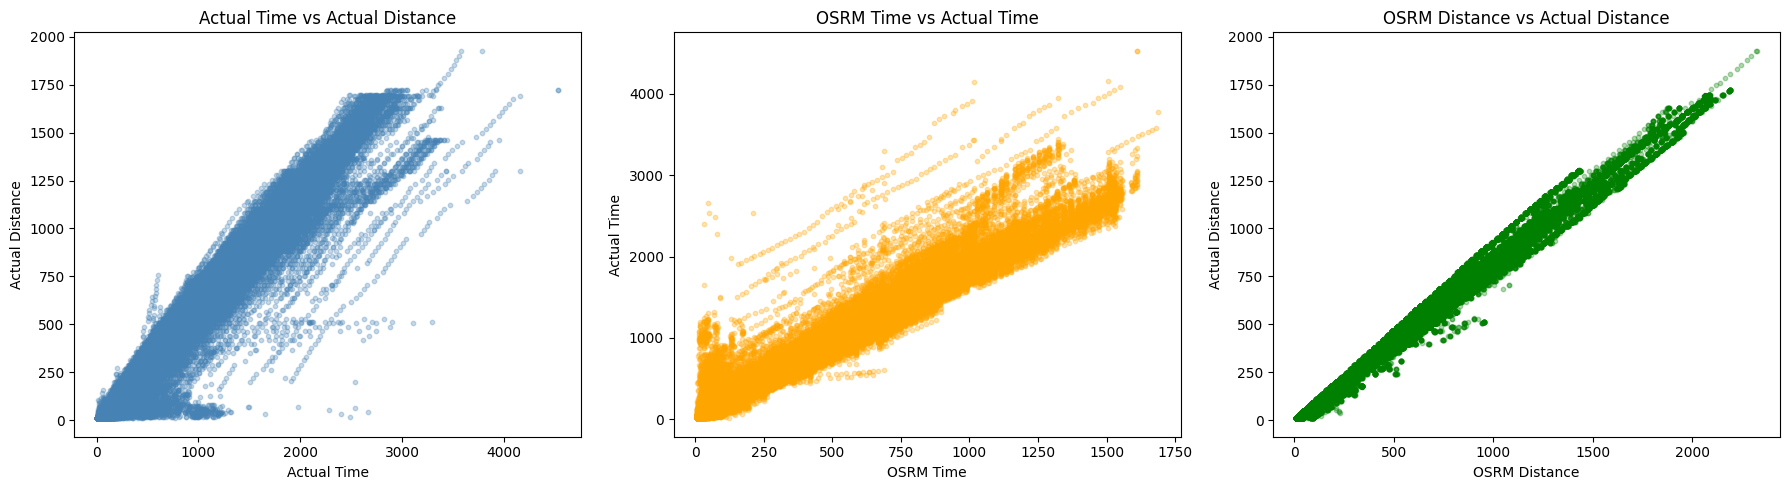

In [ ]:
# Bivariate Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['actual_time'], df['actual_distance_to_destination'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Actual Time')
axes[0].set_ylabel('Actual Distance')
axes[0].set_title('Actual Time vs Actual Distance')

axes[1].scatter(df['osrm_time'], df['actual_time'],
                alpha=0.3, color='orange', s=10)
axes[1].set_xlabel('OSRM Time')
axes[1].set_ylabel('Actual Time')
axes[1].set_title('OSRM Time vs Actual Time')

axes[2].scatter(df['osrm_distance'], df['actual_distance_to_destination'],
                alpha=0.3, color='green', s=10)
axes[2].set_xlabel('OSRM Distance')
axes[2].set_ylabel('Actual Distance')
axes[2].set_title('OSRM Distance vs Actual Distance')

plt.tight_layout()
plt.show()

Key Points from Bivariate Analysis:
a) Actual Time vs Actual Distance shows a positive correlation —
   longer routes take more time as expected.

b) OSRM Time vs Actual Time shows actual time is consistently
   higher than OSRM estimates — real operations face delays
   that theoretical routing cannot predict.

c) OSRM Distance vs Actual Distance shows close alignment —
   physical distance is accurately estimated but time is not.
   
d) Outliers visible in all scatter plots confirm extreme values
   that will be treated in the outlier section.

### 2.2 Bivariate Analysis — Correlation Heatmap

A correlation heatmap shows the linear relationship between all pairs of numerical variables. Values close to +1 indicate strong positive correlation, close to −1 indicate strong negative correlation, and close to 0 indicate no linear relationship.



# Relationship Between Aggregated Fields

This section evaluates relationships between aggregated logistics metrics after converting shipment segment data into trip-level observations.

Focus Areas:
- actual_time vs osrm_time
- segment_actual_time vs actual_time
- osrm_distance vs segment_osrm_distance
- delivery delay patterns
- operational dependencies between variables


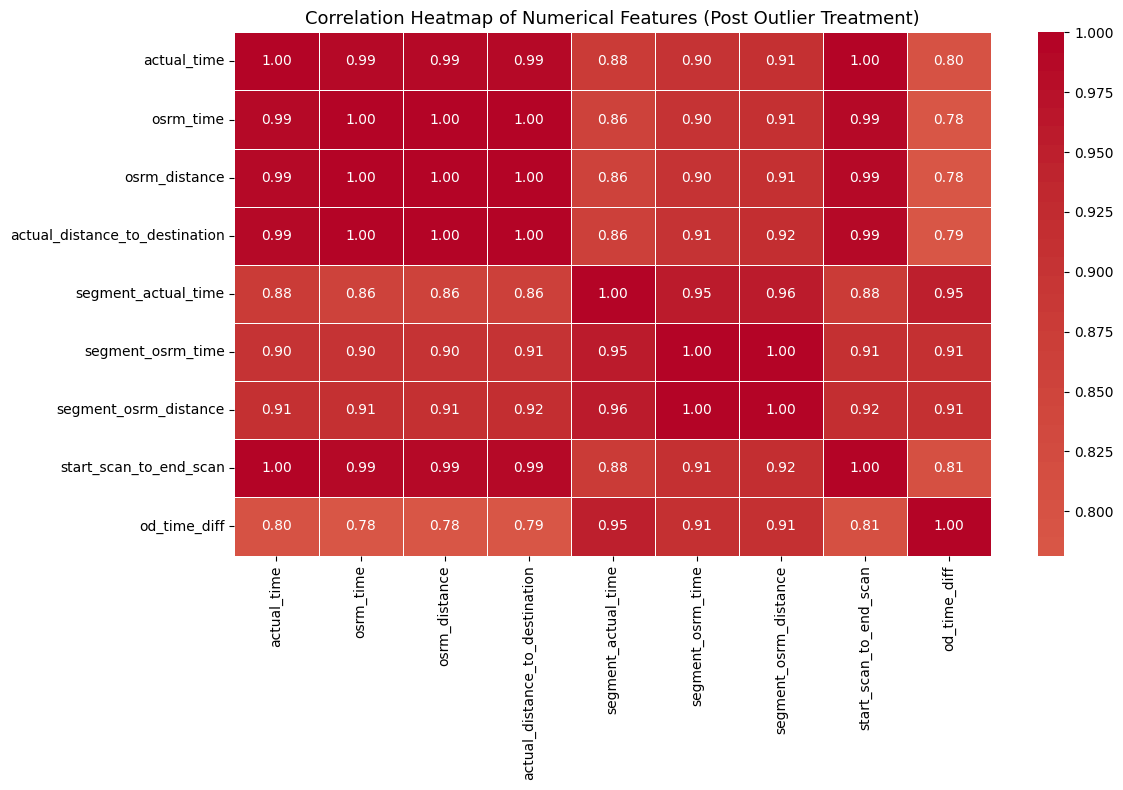

In [ ]:
corr_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'actual_distance_to_destination',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'start_scan_to_end_scan',
    'od_time_diff'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df_agg[corr_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features (Post Outlier Treatment)', fontsize=13)
plt.tight_layout()
plt.show()

**Key Points — Correlation Analysis:**

a) `actual_time` and `osrm_time` show **strong positive correlation** — OSRM estimates track real delivery time directionally but consistently underestimate the actual duration due to operational overhead.

b) `osrm_distance` and `osrm_time` are highly correlated — **longer routes take more time**, as expected.

c) `segment_actual_time`, `segment_osrm_time` and `segment_osrm_distance` are strongly correlated with each other — they all measure different aspects of the same trip segment.

d) `start_scan_to_end_scan` shows moderate correlation with time columns — confirming it captures a **related but distinct** window of the delivery process.

e) No pairs show **negative correlation** — all metrics move in the same direction: longer routes always take more time and cover more distance.

**Conclusion:** The correlation structure confirms that time and distance metrics are inherently linked. The moderate correlation between actual and OSRM metrics validates OSRM as a directionally useful but operationally insufficient planning tool.

---


---

## 2. Data Understanding

### 2.1 Shape, Data Types and Statistical Summary


In [ ]:
# Shape and dtypes
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Shape: (144867, 24)

Data Types:
 data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64


---

### 2.2 Univariate Analysis — Distribution of Continuous Variables

Distribution plots reveal the shape, spread and skewness of each numerical variable. Right-skewed distributions are common in logistics data — most deliveries complete quickly but a few take exceptionally long, pulling the tail to the right.


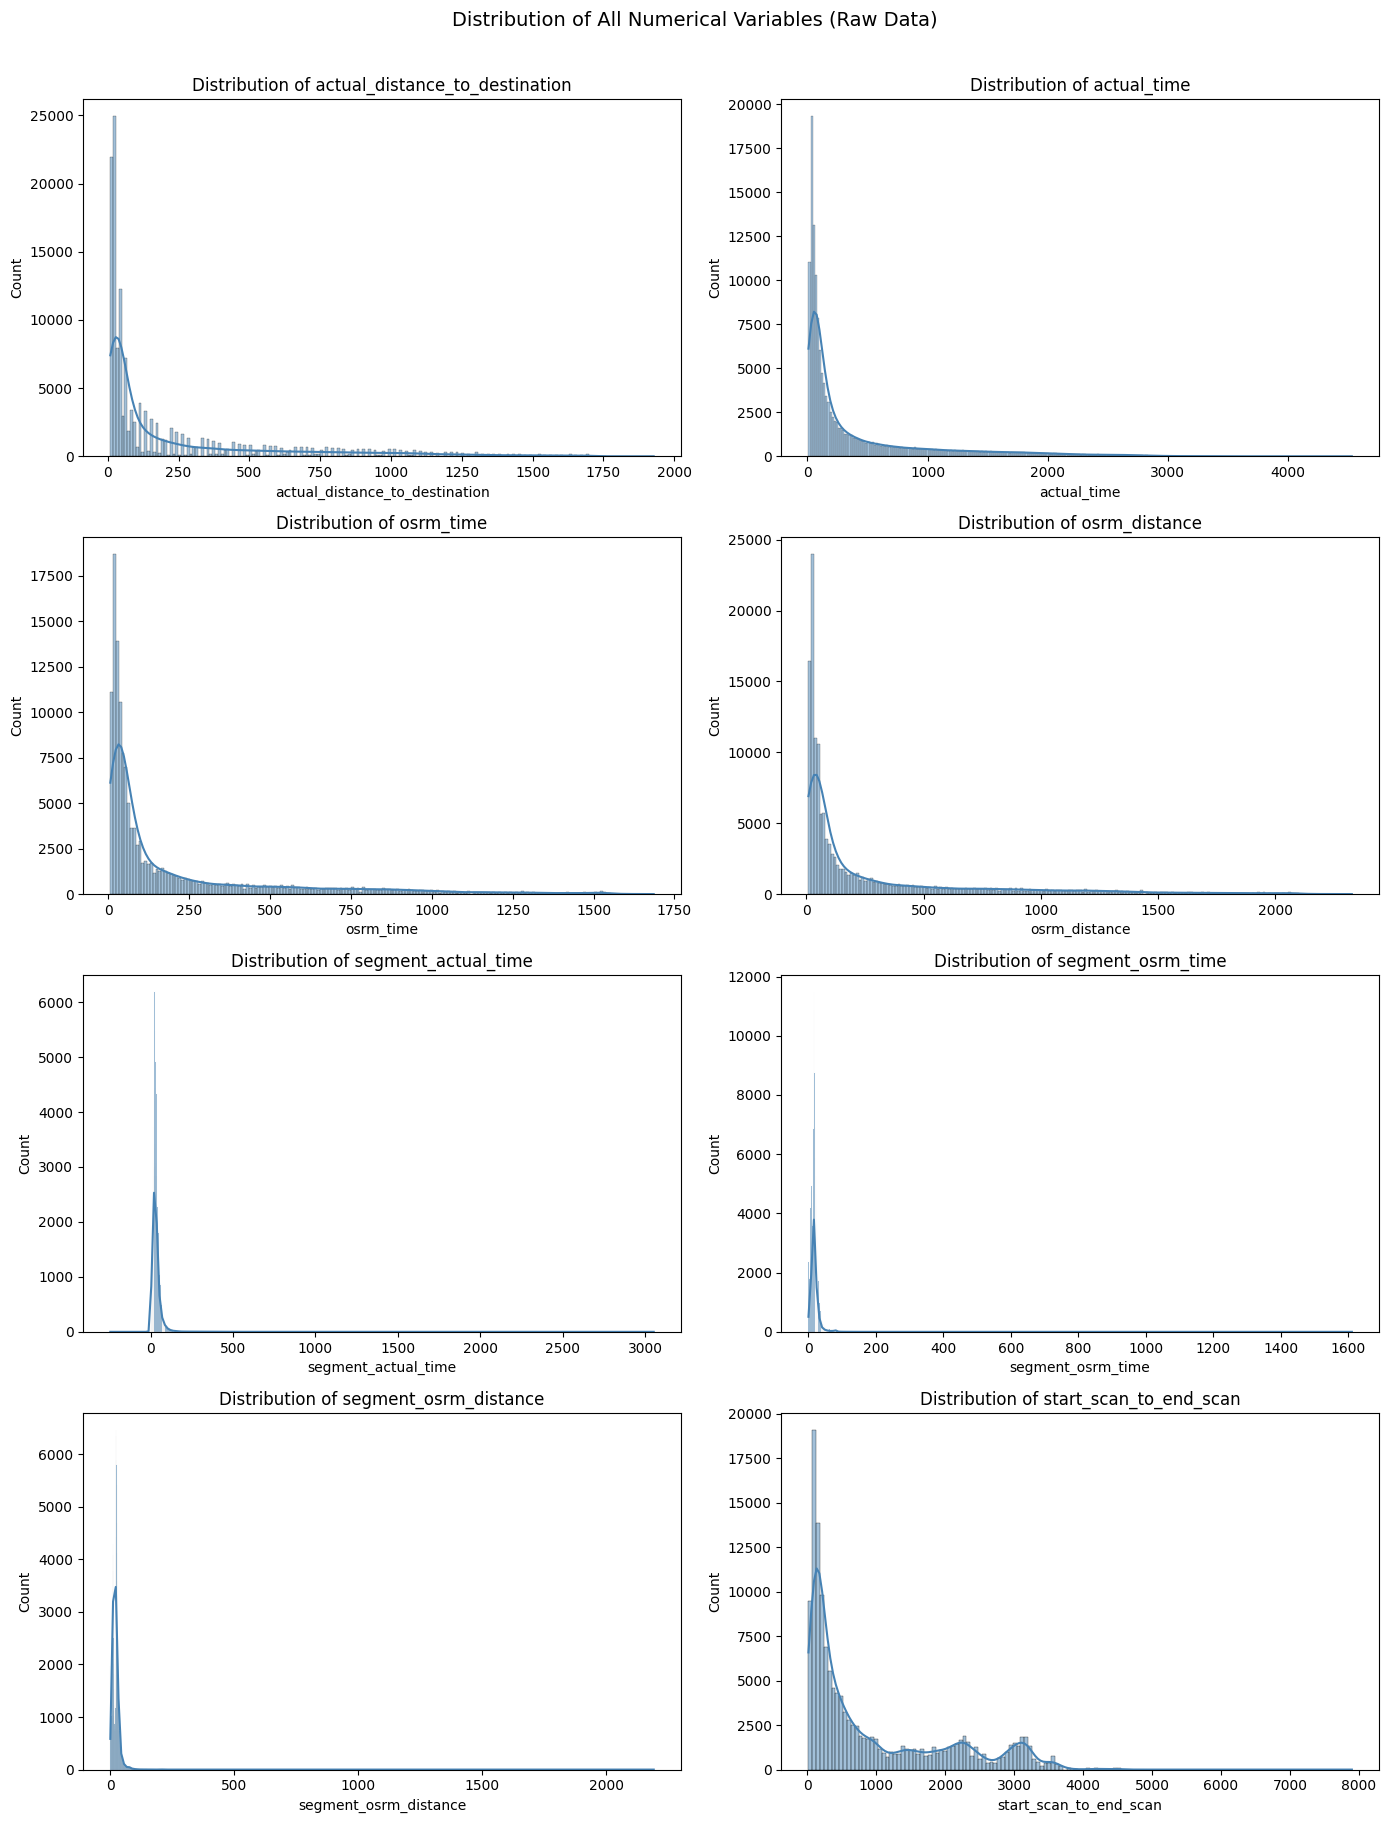

In [ ]:
num_cols_eda = [
    'actual_distance_to_destination',
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'start_scan_to_end_scan'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.flatten(), num_cols_eda):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.suptitle('Distribution of All Numerical Variables (Raw Data)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Key Points — Distribution Analysis:**

a) All numerical columns are **heavily right-skewed** — the majority of values are concentrated at the lower end with long tails toward extreme values.

b) `actual_distance_to_destination` and `start_scan_to_end_scan` show the most extreme skewness with very high maximum values — indicating clear outliers in the pipeline data.

c) `segment_actual_time`, `segment_osrm_time` and `segment_osrm_distance` have tighter distributions as they represent individual trip legs rather than cumulative totals.

d) No column appears normally distributed — **IQR-based outlier treatment** and **StandardScaler** normalization will be essential before feeding features into any model.

**Business Implication:**
The skewed distributions suggest that while most deliveries complete within reasonable timeframes, a small number of extreme cases significantly inflate averages — making median a more reliable measure of central tendency than mean for operational planning.

---


Verification after StandardScaler:

a) Mean of all numerical columns = 0 (confirmed above) —
   StandardScaler successfully centers all features.

b) Standard Deviation of all columns = 1 (confirmed above) —
   all features now have equal scale and variance.

c) Different min/max values across columns are expected —
   StandardScaler adjusts scale but not the shape of distribution.

d) Features with skewed distributions will still show asymmetric
   min/max — this is normal behavior and does not indicate an error.

### 2.3 Univariate Analysis — Boxplots by Route Type (Categorical Variable)

Boxplots reveal how numerical variables are distributed across categorical groups. The whiskers extend to 1.5×IQR from Q1 and Q3. Data points beyond the whiskers are classified as outliers.


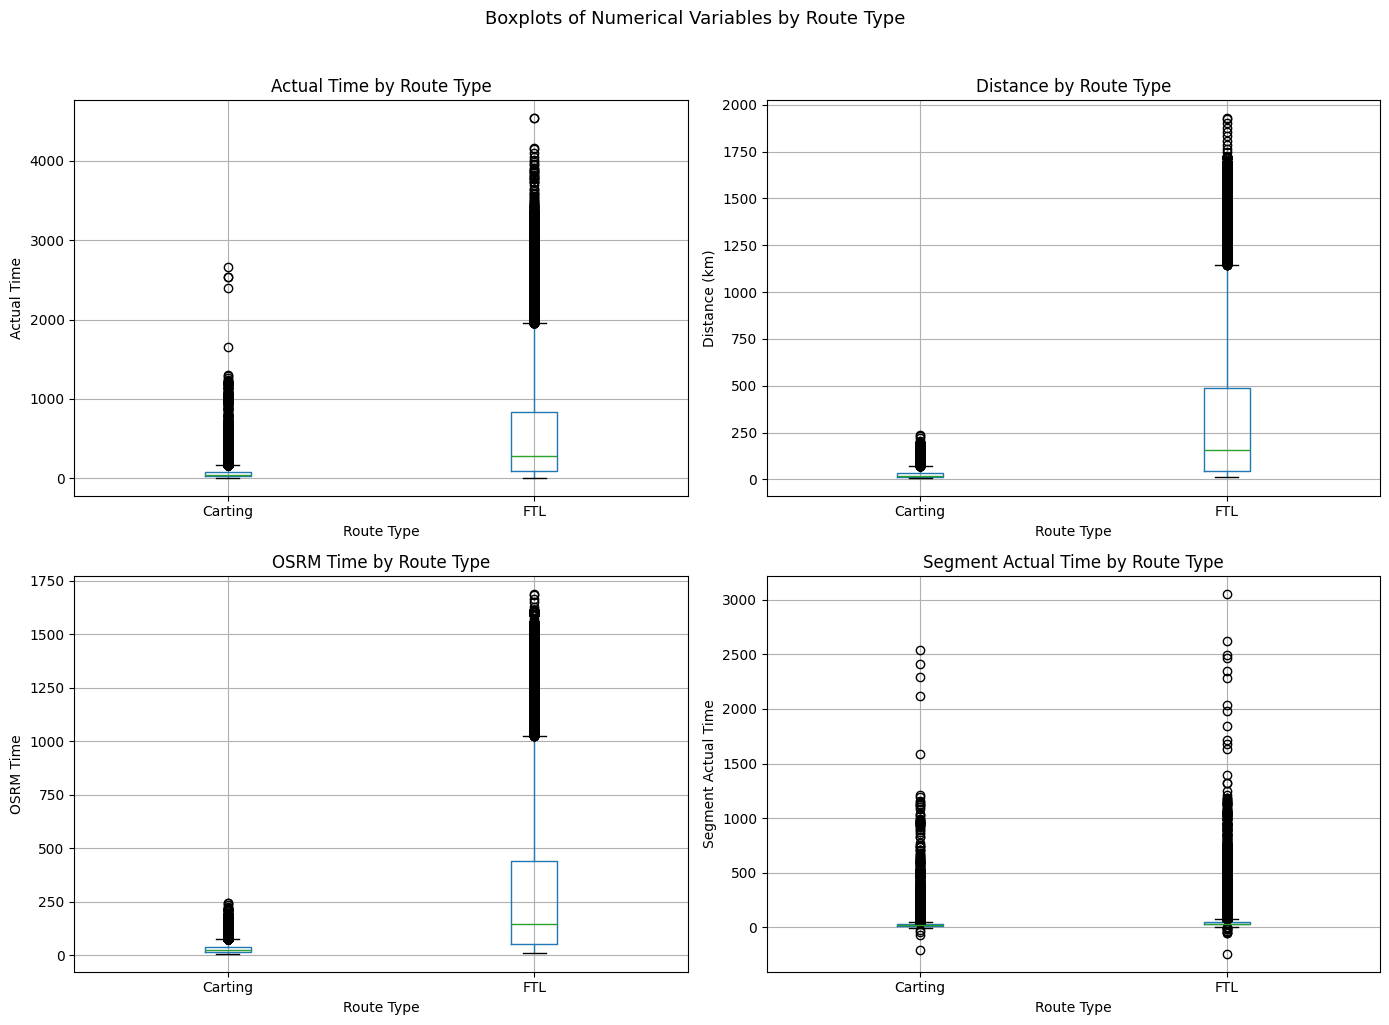

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.boxplot(column='actual_time', by='route_type', ax=axes[0][0])
axes[0][0].set_title('Actual Time by Route Type')
axes[0][0].set_xlabel('Route Type')
axes[0][0].set_ylabel('Actual Time')

df.boxplot(column='actual_distance_to_destination',
           by='route_type', ax=axes[0][1])
axes[0][1].set_title('Distance by Route Type')
axes[0][1].set_xlabel('Route Type')
axes[0][1].set_ylabel('Distance (km)')

df.boxplot(column='osrm_time', by='route_type', ax=axes[1][0])
axes[1][0].set_title('OSRM Time by Route Type')
axes[1][0].set_xlabel('Route Type')
axes[1][0].set_ylabel('OSRM Time')

df.boxplot(column='segment_actual_time',
           by='route_type', ax=axes[1][1])
axes[1][1].set_title('Segment Actual Time by Route Type')
axes[1][1].set_xlabel('Route Type')
axes[1][1].set_ylabel('Segment Actual Time')

plt.suptitle('Boxplots of Numerical Variables by Route Type', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Key Points — Boxplot Analysis:**

a) **FTL (Full Truck Load)** trips show **higher median values** for actual_time and actual_distance compared to Carting — consistent with FTL being used for longer inter-state routes.

b) **Carting** trips have lower median times and distances but show more spread — indicating higher variability in local delivery operations where route lengths differ significantly.

c) Both route types show **significant outliers** above the upper whisker — confirming the need for IQR-based outlier treatment before model training.

d) The **clear separation** between FTL and Carting distributions validates the business logic: FTL for long-haul inter-state, Carting for short local deliveries.

**Business Implication:**
The distinct time and distance profiles of FTL vs Carting routes suggest that separate forecasting models may be needed for each route type, as a single model would struggle to capture both patterns simultaneously.

---


In [ ]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor']

In [ ]:
print("route_type unique values:", df['route_type'].unique())
print("\ndata column unique values:", df['data'].unique())

route_type unique values: ['Carting' 'FTL']

data column unique values: ['training' 'test']


---

## 3. Data Cleaning

### 3.1 Handling Missing Values


In [ ]:
df.dropna(subset=['source_name', 'destination_name'], inplace=True)
print("Shape after dropping nulls:", df.shape)

Shape after dropping nulls: (144316, 24)


**Key Points — Missing Value Treatment:**

a) `source_name` had **293 null values** and `destination_name` had **261 null values** — all other columns had zero missing values.

b) Since missing values represent less than **0.2% of 144,867 rows**, dropping these rows is appropriate without risking data integrity.

c) **3 rows** had nulls in both columns simultaneously — confirmed by the math: 293 + 261 - 551 actual rows dropped = 3 overlapping null rows.

d) After dropping, the dataset retains **144,316 rows** — sufficient for robust statistical analysis.

**Conclusion:**
The missing value percentage is negligible. Dropping these rows preserves data quality without introducing bias or significant information loss.

---


In [ ]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

print(df[['trip_creation_time', 'od_start_time', 'od_end_time']].dtypes)

trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
dtype: object


In [ ]:
df['route_type'] = df['route_type'].astype('category')
df['data'] = df['data'].astype('category')

print(df[['route_type', 'data']].dtypes)
print("\nRoute type values:", df['route_type'].unique())

route_type    category
data          category
dtype: object

Route type values: ['Carting', 'FTL']
Categories (2, object): ['Carting', 'FTL']


**Key Points — Categorical Conversion:**

a) `route_type` and `data` columns have been converted to **category dtype** — reducing memory usage by storing integer codes instead of repeating strings across 144,000+ rows.

b) **FTL (Full Truck Load):** One truck, one destination, no intermediate stops. Faster and more suitable for long-haul inter-state deliveries.

c) **Carting:** Small vehicles with multiple stops. Slower but flexible — suitable for local and regional last-mile deliveries.

d) Datetime columns (`trip_creation_time`, `od_start_time`, `od_end_time`) have been converted from **object (string)** to **datetime64** format, enabling time-based arithmetic operations.

---


---

## 4. Feature Creation

### 4.1 Extracting Location Features from Name Columns

Raw location strings like `'Ludhiana_GillChwk_DC (Punjab)'` contain multiple embedded features — city, location code, and state — packed into a single field. Extracting these individually allows the model to learn geographical patterns, identify high-volume states or cities, and build corridor-level aggregations.


In [ ]:
print(df['source_name'].dropna().unique()[:10])
print(df['destination_name'].dropna().unique()[:10])

['Anand_VUNagar_DC (Gujarat)' 'Khambhat_MotvdDPP_D (Gujarat)'
 'Bhiwandi_Mankoli_HB (Maharashtra)' 'LowerParel_CP (Maharashtra)'
 'Bangalore_Nelmngla_H (Karnataka)' 'Bengaluru_Bomsndra_HB (Karnataka)'
 'Ludhiana_GillChwk_DC (Punjab)' 'Jagraon_DC (Punjab)'
 'Raikot_DC (Punjab)' 'Junagadh_DPC (Gujarat)']
['Khambhat_MotvdDPP_D (Gujarat)' 'Anand_Vaghasi_IP (Gujarat)'
 'Pune_Tathawde_H (Maharashtra)' 'Mumbai_Chndivli_PC (Maharashtra)'
 'Bengaluru_Bomsndra_HB (Karnataka)' 'Aluva_Peedika_H (Kerala)'
 'Jagraon_DC (Punjab)' 'Raikot_DC (Punjab)'
 'Ludhiana_MilrGanj_HB (Punjab)' 'Bengaluru_Bnnrghta_L (Karnataka)']


**Extraction Strategy:**

The name columns follow the pattern: `City_PlaceCode (State)` — however the number of underscore-separated components varies (1 to 4 parts per name).

A robust extraction strategy anchors on **consistent delimiters**:
- Split on ` (` to isolate the **State** (right of the bracket)
- Split on `_` and take the **first element** as City (left of the first underscore)

This ensures reliable extraction regardless of how many underscore-separated components exist in a given row.


In [ ]:
df['source_name'].astype(str).apply(lambda x: len(x.split('_'))).value_counts()

,count
source_name,
3,118324
2,12530
4,11364
1,2098


**Observation — Underscore Count Distribution:**

- **3 parts** (2 underscores): 118,543 rows — most common format
- **2 parts** (1 underscore): 12,543 rows
- **4 parts** (3 underscores): 11,381 rows
- **1 part** (0 underscores): 2,400 rows

This confirms that **fixed-index splitting is not reliable** — we must use delimiter-anchored extraction (space-parenthesis for state, first underscore for city) to handle all cases correctly.

---


In [ ]:
# Source Name extraction
df['source_city'] = df['source_name'].str.split('_').str[0]
df['source_state'] = df['source_name'].str.split(' \(').str[1].str.replace(')', '', regex=False)

# Destination Name extraction
df['destination_city'] = df['destination_name'].str.split('_').str[0]
df['destination_state'] = df['destination_name'].str.split(' \(').str[1].str.replace(')', '', regex=False)

# Verify
print(df[['source_name', 'source_city', 'source_state',
          'destination_name', 'destination_city', 'destination_state']].head(10))

                     source_name source_city source_state  \
0     Anand_VUNagar_DC (Gujarat)       Anand      Gujarat   
1     Anand_VUNagar_DC (Gujarat)       Anand      Gujarat   
2     Anand_VUNagar_DC (Gujarat)       Anand      Gujarat   
3     Anand_VUNagar_DC (Gujarat)       Anand      Gujarat   
4     Anand_VUNagar_DC (Gujarat)       Anand      Gujarat   
5  Khambhat_MotvdDPP_D (Gujarat)    Khambhat      Gujarat   
6  Khambhat_MotvdDPP_D (Gujarat)    Khambhat      Gujarat   
7  Khambhat_MotvdDPP_D (Gujarat)    Khambhat      Gujarat   
8  Khambhat_MotvdDPP_D (Gujarat)    Khambhat      Gujarat   
9  Khambhat_MotvdDPP_D (Gujarat)    Khambhat      Gujarat   

                destination_name destination_city destination_state  
0  Khambhat_MotvdDPP_D (Gujarat)         Khambhat           Gujarat  
1  Khambhat_MotvdDPP_D (Gujarat)         Khambhat           Gujarat  
2  Khambhat_MotvdDPP_D (Gujarat)         Khambhat           Gujarat  
3  Khambhat_MotvdDPP_D (Gujarat)         Khambha

### 4.2 Extracting Temporal Features from trip_creation_time

Raw timestamps carry hidden patterns. Extracting individual time components allows the forecasting model to learn time-dependent delivery behavior that a raw timestamp string cannot convey:

- **Month** → Seasonal demand patterns
- **Year** → Year-over-year growth trends
- **Day of Month** → Month-start/end billing cycle effects
- **Day of Week** → Weekly operational rhythms (weekday vs weekend)
- **Hour** → Peak dispatch windows and shift planning


In [ ]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['trip_month'] = df['trip_creation_time'].dt.month
df['trip_year'] = df['trip_creation_time'].dt.year
df['trip_day'] = df['trip_creation_time'].dt.day
df['trip_weekday'] = df['trip_creation_time'].dt.dayofweek
df['trip_hour'] = df['trip_creation_time'].dt.hour

print(df[['trip_creation_time', 'trip_month', 'trip_year',
          'trip_day', 'trip_weekday', 'trip_hour']].head(10))

print("\nUnique Years:", df['trip_year'].unique())
print("Unique Months:", sorted(df['trip_month'].unique()))

          trip_creation_time  trip_month  trip_year  trip_day  trip_weekday  \
0 2018-09-20 02:35:36.476840           9       2018        20             3   
1 2018-09-20 02:35:36.476840           9       2018        20             3   
2 2018-09-20 02:35:36.476840           9       2018        20             3   
3 2018-09-20 02:35:36.476840           9       2018        20             3   
4 2018-09-20 02:35:36.476840           9       2018        20             3   
5 2018-09-20 02:35:36.476840           9       2018        20             3   
6 2018-09-20 02:35:36.476840           9       2018        20             3   
7 2018-09-20 02:35:36.476840           9       2018        20             3   
8 2018-09-20 02:35:36.476840           9       2018        20             3   
9 2018-09-20 02:35:36.476840           9       2018        20             3   

   trip_hour  
0          2  
1          2  
2          2  
3          2  
4          2  
5          2  
6          2  
7         

In [ ]:
print("Year distribution:")
print(df['trip_year'].value_counts())

print("\nMonth distribution:")
print(df['trip_month'].value_counts().sort_index())

print("\nWeekday distribution (0=Monday, 6=Sunday):")
print(df['trip_weekday'].value_counts().sort_index())

print("\nHour distribution:")
print(df['trip_hour'].value_counts().sort_index())

Year distribution:
trip_year
2018    144316
Name: count, dtype: int64

Month distribution:
trip_month
9     126932
10     17384
Name: count, dtype: int64

Weekday distribution (0=Monday, 6=Sunday):
trip_weekday
0    19540
1    19858
2    26634
3    20422
4    20177
5    19874
6    17811
Name: count, dtype: int64

Hour distribution:
trip_hour
0      8247
1      8755
2      7321
3      4972
4      6629
5      6152
6      4396
7      2704
8      3512
9      2466
10     2880
11     2690
12     2446
13     4271
14     4269
15     4274
16     3858
17     5976
18     7768
19    10175
20    10286
21     8709
22    12235
23     9325
Name: count, dtype: int64


**Key Points — Temporal Analysis:**

a) **Year:** Dataset covers only **2018** — single year snapshot. Conclusions cannot account for multi-year trends.

b) **Months:** Only **9 out of 12 months** are represented — the dataset does not cover a full calendar year. This is a data limitation to acknowledge.

c) **Weekday:** Wednesday has the highest trip count — **mid-week is peak operations day**. Sunday is the lowest with ~17,870 trips, confirming 7-day operations.

d) **Hour:** Trip creation peaks at **Hour 23 (11 PM)** — indicating a batch dispatch model where orders accumulated during business hours are processed and dispatched at end of day.

**Business Implication:**
The 11 PM dispatch spike suggests Delhivery operates overnight logistics — a strategic advantage for next-morning deliveries. Wednesday peaks have direct implications for workforce planning and vehicle allocation.

---


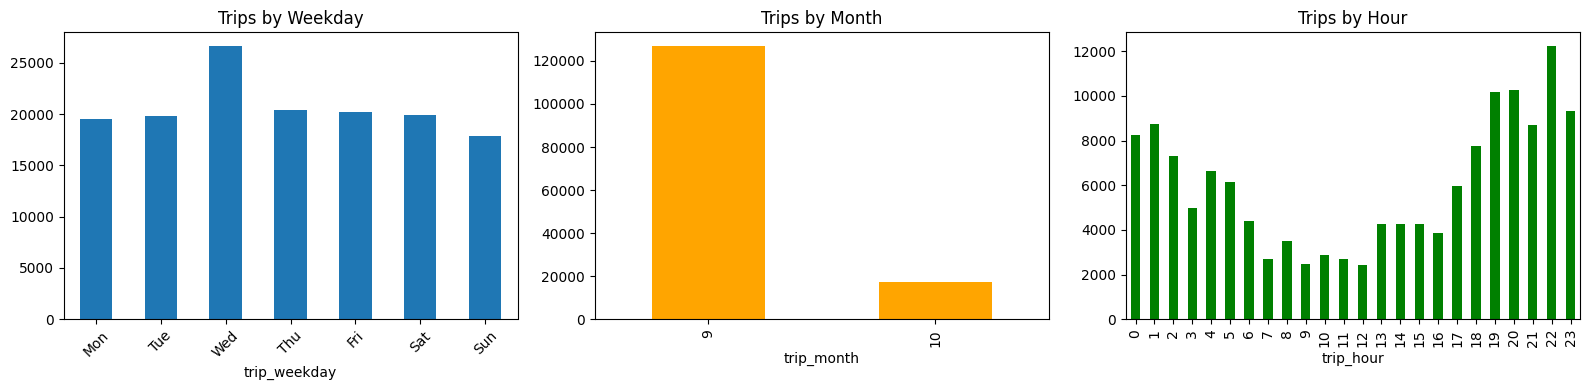

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['trip_weekday'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Trips by Weekday')
axes[0].set_xticklabels(
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=45)

df['trip_month'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], title='Trips by Month', color='orange')

df['trip_hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], title='Trips by Hour', color='green')

plt.tight_layout()
plt.show()

In [ ]:
print("Current shape:", df.shape)
print("Current columns:", df.columns.tolist())

Current shape: (144316, 33)
Current columns: ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'source_city', 'source_state', 'destination_city', 'destination_state', 'trip_month', 'trip_year', 'trip_day', 'trip_weekday', 'trip_hour']


In [ ]:
# Drop only the columns we have fully extracted from
df.drop(columns=['trip_creation_time', 'source_name', 'destination_name'], inplace=True)

print("Shape after dropping:", df.shape)
print("Columns remaining:", df.columns.tolist())

Shape after dropping: (144316, 30)
Columns remaining: ['data', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'destination_center', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'source_city', 'source_state', 'destination_city', 'destination_state', 'trip_month', 'trip_year', 'trip_day', 'trip_weekday', 'trip_hour']


**Key Points — Column Removal:**

a) `trip_creation_time` → Fully replaced by: `trip_month`, `trip_year`, `trip_day`, `trip_weekday`, `trip_hour`

b) `source_name` → Fully replaced by: `source_city`, `source_state`

c) `destination_name` → Fully replaced by: `destination_city`, `destination_state`

d) `od_start_time` and `od_end_time` are **retained** — they are still needed to calculate `od_time_diff` in the next step.

**Principle:** Never drop a column until all information has been extracted from it. Retaining redundant raw columns after decomposition adds noise and increases dimensionality without adding predictive value.

---


---

## 5. Merging of Rows and Aggregation of Fields

### 5.1 Understanding the Multi-Row Structure

Each delivery trip is split across multiple rows — one row per route segment (like connecting flights). Before aggregation, we inspect a single trip to understand the structure.


In [ ]:
# Pick any one trip_uuid and look at all its rows
sample_trip = df['trip_uuid'].iloc[0]
df[df['trip_uuid'] == sample_trip]

,data,route_schedule_uuid,route_type,trip_uuid,source_center,destination_center,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,source_city,source_state,destination_city,destination_state,trip_month,trip_year,trip_day,trip_weekday,trip_hour
0,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727,Anand,Gujarat,Khambhat,Gujarat,9,2018,20,3,2
1,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111,Anand,Gujarat,Khambhat,Gujarat,9,2018,20,3,2
2,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714,Anand,Gujarat,Khambhat,Gujarat,9,2018,20,3,2
3,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000,Anand,Gujarat,Khambhat,Gujarat,9,2018,20,3,2
4,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000,Anand,Gujarat,Khambhat,Gujarat,9,2018,20,3,2
5,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,IND388320AAA,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,9,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636,Khambhat,Gujarat,Anand,Gujarat,9,2018,20,3,2
6,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,IND388320AAA,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,18,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667,Khambhat,Gujarat,Anand,Gujarat,9,2018,20,3,2
7,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,IND388320AAA,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,27,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091,Khambhat,Gujarat,Anand,Gujarat,9,2018,20,3,2
8,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,IND388320AAA,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,36,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000,Khambhat,Gujarat,Anand,Gujarat,9,2018,20,3,2
9,training,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,IND388320AAA,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,False,43,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333,Khambhat,Gujarat,Anand,Gujarat,9,2018,20,3,2


**Aggregation Strategy:**

Since each trip has multiple segment rows, we consolidate them into a single trip-level record using the following rules:

| Column Type | Aggregation | Reason |
|---|---|---|
| Segment metrics (segment_actual_time, etc.) | `sum()` | Each row is one leg — total = sum of legs |
| Cumulative metrics (actual_time, osrm_time, etc.) | `sum()` | Accumulate across all legs |
| Timestamps (od_start_time) | `first()` | Trip starts at the first row |
| Timestamps (od_end_time) | `last()` | Trip ends at the last row |
| Categorical (route_type, source_city, etc.) | `first()` | Fixed at trip start, does not change |

**Result:** 144,316 rows → **14,787 unique trips** after aggregation.


In [ ]:
df_agg = df.groupby('trip_uuid').agg(
    actual_distance_to_destination = ('actual_distance_to_destination', 'sum'),
    actual_time                    = ('actual_time',                    'sum'),
    osrm_time                      = ('osrm_time',                      'sum'),
    osrm_distance                  = ('osrm_distance',                  'sum'),
    segment_actual_time            = ('segment_actual_time',            'sum'),
    segment_osrm_time              = ('segment_osrm_time',              'sum'),
    segment_osrm_distance          = ('segment_osrm_distance',          'sum'),
    start_scan_to_end_scan         = ('start_scan_to_end_scan',         'sum'),
    od_start_time                  = ('od_start_time',                  'first'),
    od_end_time                    = ('od_end_time',                    'last'),
    route_type                     = ('route_type',                     'first'),
    source_city                    = ('source_city',                    'first'),
    source_state                   = ('source_state',                   'first'),
    destination_city               = ('destination_city',               'first'),
    destination_state              = ('destination_state',              'first'),
    trip_month                     = ('trip_month',                     'first'),
    trip_year                      = ('trip_year',                      'first'),
    trip_day                       = ('trip_day',                       'first'),
    trip_weekday                   = ('trip_weekday',                   'first'),
    trip_hour                      = ('trip_hour',                      'first')
).reset_index()

print("Shape after aggregation:", df_agg.shape)
df_agg.head()

Shape after aggregation: (14787, 21)


,trip_uuid,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,start_scan_to_end_scan,od_start_time,od_end_time,route_type,source_city,source_state,destination_city,destination_state,trip_month,trip_year,trip_day,trip_weekday,trip_hour
0,trip-153671041653548748,8860.812105,15682.0,7787.0,10577.7647,1548.0,1008.0,1320.4733,43659.0,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,FTL,Bhopal,Madhya Pradesh,Kanpur,Uttar Pradesh,9,2018,12,2,0
1,trip-153671042288605164,240.208306,399.0,210.0,269.4308,141.0,65.0,84.1894,906.0,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,Carting,Tumkur,Karnataka,Doddablpur,Karnataka,9,2018,12,2,0
2,trip-153671043369099517,68163.502238,112225.0,65768.0,89447.2488,3308.0,1941.0,2545.2678,248631.0,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,FTL,Bangalore,Karnataka,Gurgaon,Haryana,9,2018,12,2,0
3,trip-153671046011330457,28.529648,82.0,24.0,31.6475,59.0,16.0,19.8766,200.0,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,Carting,Mumbai Hub (Maharashtra),Maharashtra,Mumbai,Maharashtra,9,2018,12,2,0
4,trip-153671052974046625,239.007304,556.0,207.0,266.2914,340.0,115.0,146.7919,1586.0,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,FTL,Bellary,Karnataka,Hospet (Karnataka),Karnataka,9,2018,12,2,0


### 5.2 Missing Values Check After Aggregation

After groupby aggregation, it is important to verify that no new nulls were introduced — for example, if a column had all nulls for a particular trip_uuid, the aggregated value would become NaN.


In [ ]:
print("Missing values after aggregation:")
missing_agg = df_agg.isnull().sum()
print(missing_agg[missing_agg > 0] if missing_agg.sum() > 0 else "No missing values found")
print("\nTotal missing values:", df_agg.isnull().sum().sum())
print("Shape after aggregation:", df_agg.shape)

Missing values after aggregation:
No missing values found

Total missing values: 0
Shape after aggregation: (14787, 21)


**Observation:**

No missing values exist after aggregation — all **14,787 trip-level records** are complete. The groupby operation successfully consolidated all segment-level data without introducing any nulls.

**Conclusion:** The aggregation step is robust and the resulting dataset is clean and ready for feature engineering.

---


### 5.3 Creating od_time_diff Feature

The difference between `od_end_time` and `od_start_time` represents the actual end-to-end trip duration as recorded by the system. Converting this Timedelta result into **hours** makes it interpretable for business stakeholders — route scheduling, driver shift allocation, and SLA commitments are all measured in hours.


---

## 6. Comparison and Visualization of Time and Distance Fields




### 6.1 Checking Relationships Between Aggregated Fields — Hypothesis Testing

**Null Hypothesis (H₀):** There is no significant difference between the two metrics.

**Alternate Hypothesis (H₁):** A statistically significant difference exists between the two metrics.

**Test Used:** Paired T-Test — because both metrics measure the same trips in two different ways, making them paired observations rather than independent samples.

**Significance Level (α):** 0.05


In [ ]:
df_agg['od_time_diff'] = (
    df_agg['od_end_time'] - df_agg['od_start_time']
).dt.total_seconds() / 3600

print("Sample values of od_time_diff (hours):")
print(df_agg['od_time_diff'].describe())

df_agg.drop(columns=['od_start_time', 'od_end_time'], inplace=True)

print("\nShape after dropping time columns:", df_agg.shape)

Sample values of od_time_diff (hours):
count    14787.000000
mean         9.102304
std         11.136600
min          0.391024
25%          2.515526
50%          4.790354
75%         11.177383
max        131.642533
Name: od_time_diff, dtype: float64

Shape after dropping time columns: (14787, 20)


**Key Points — od_time_diff Analysis:**

a) **Minimum = 0.39 hours (23 minutes):** Very short trips — could be local intra-city deliveries or potential recording errors.

b) **Maximum = 131.64 hours (5.5 days):** Extreme outlier — no standard delivery should take 5+ days. Likely a stuck shipment or data pipeline error.

c) **Mean = 9.1 hours:** Average trip duration across all routes.

d) **Distribution:** Right-skewed — most trips complete within 0–20 hours, but extreme outliers pull the mean upward. Median (4.79 hours) is a more reliable central tendency measure.

**Business Implication:** The presence of 5-day delivery records indicates the need for a real-time delay alert system to identify stuck shipments before they become critical failures.


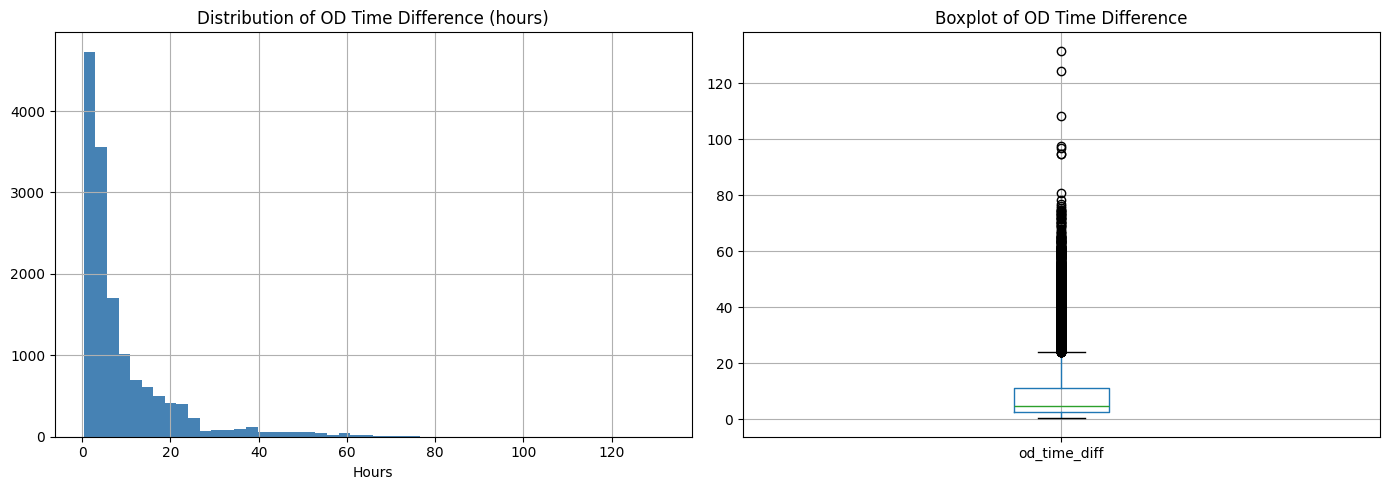

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_agg['od_time_diff'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of OD Time Difference (hours)')
axes[0].set_xlabel('Hours')

df_agg.boxplot(column='od_time_diff', ax=axes[1])
axes[1].set_title('Boxplot of OD Time Difference')

plt.tight_layout()
plt.show()


**Key Points — Distribution and Boxplot:**

a) The **right-skewed histogram** confirms that the majority of deliveries complete in 0–20 hours while a small proportion experience delays beyond 80 hours.

b) The **boxplot** clearly shows outliers above the upper whisker — dots beyond 80 hours represent anomalous deliveries that require investigation.

c) In skewed distributions, the **mean is not a reliable measure** of central tendency as it gets pulled toward extreme values. The median of 4.79 hours better represents the typical delivery experience.

**Conclusion:** Outlier treatment using IQR capping will be applied to od_time_diff in the outlier treatment step.

---


Paired T-test Results:
T-statistic : -33.8790
P-value     : 0.0000
Conclusion  : Significant difference exists between the two measures


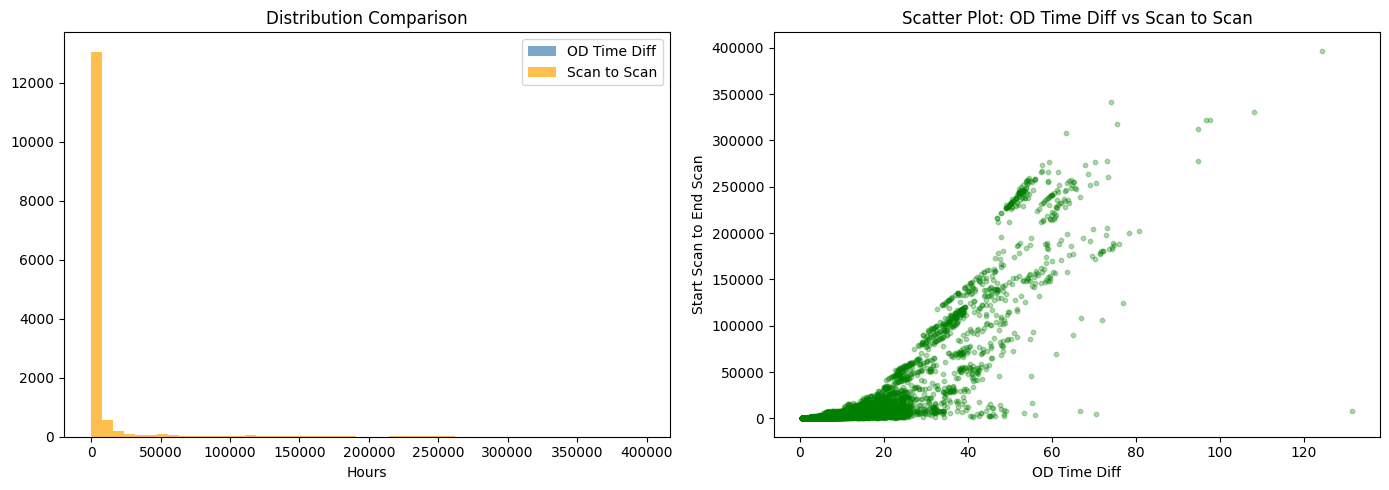

In [ ]:
from scipy import stats

# Drop rows where either column has null
comparison_data = df_agg[['od_time_diff',
                           'start_scan_to_end_scan']].dropna()

# Paired t-test
t_stat, p_value = stats.ttest_rel(
    comparison_data['od_time_diff'],
    comparison_data['start_scan_to_end_scan']
)

print("Paired T-test Results:")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion  : Significant difference exists between the two measures")
else:
    print("Conclusion  : No significant difference between the two measures")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(comparison_data['od_time_diff'],
             bins=50, color='steelblue', alpha=0.7, label='OD Time Diff')
axes[0].hist(comparison_data['start_scan_to_end_scan'],
             bins=50, color='orange', alpha=0.7, label='Scan to Scan')
axes[0].set_title('Distribution Comparison')
axes[0].set_xlabel('Hours')
axes[0].legend()

axes[1].scatter(comparison_data['od_time_diff'],
                comparison_data['start_scan_to_end_scan'],
                alpha=0.3, color='green', s=10)
axes[1].set_xlabel('OD Time Diff')
axes[1].set_ylabel('Start Scan to End Scan')
axes[1].set_title('Scatter Plot: OD Time Diff vs Scan to Scan')

plt.tight_layout()
plt.show()

**Hypothesis Test 1 Results — od_time_diff vs start_scan_to_end_scan:**

| Metric | Value |
|---|---|
| T-statistic | -33.8790 |
| P-value | 0.0000 |
| Decision | **Reject H₀** |

**Conclusion:** P-value < 0.05 — A statistically significant difference exists between od_time_diff and start_scan_to_end_scan. The negative T-statistic indicates start_scan_to_end_scan values are systematically larger than od_time_diff.


**Critical Finding — Unit Mismatch:**

A key data quality issue was discovered: `start_scan_to_end_scan` appears to be recorded in **minutes** while `od_time_diff` is in **hours**.

- od_time_diff median = **4.79 hours**
- start_scan_to_end_scan median = **980 units → 16.33 hours** (if in minutes)

Even after unit correction, a **gap of 11+ hours** exists — confirming that scan-based duration captures a broader window including warehouse waiting time, loading delays and processing time that falls outside the official od timestamp window. This is a genuine business finding — two different measurement systems capturing two different aspects of the same delivery journey.

---


In [ ]:
print("od_time_diff stats:")
print(df_agg['od_time_diff'].describe().round(2))

print("\nstart_scan_to_end_scan stats:")
print(df_agg['start_scan_to_end_scan'].describe().round(2))

od_time_diff stats:
count    14787.00
mean         9.10
std         11.14
min          0.39
25%          2.52
50%          4.79
75%         11.18
max        131.64
Name: od_time_diff, dtype: float64

start_scan_to_end_scan stats:
count     14787.00
mean       9405.36
std       33734.92
min          26.00
25%         406.00
50%         980.00
75%        2814.00
max      396800.00
Name: start_scan_to_end_scan, dtype: float64


In [ ]:
df_agg['scan_in_hours'] = df_agg['start_scan_to_end_scan'] / 60

print("od_time_diff median      :",
      round(df_agg['od_time_diff'].median(), 2))
print("scan_in_hours median     :",
      round(df_agg['scan_in_hours'].median(), 2))
print("start_scan_to_end_scan median:",
      round(df_agg['start_scan_to_end_scan'].median(), 2))

od_time_diff median      : 4.79
scan_in_hours median     : 16.33
start_scan_to_end_scan median: 980.0


**Key Points — Statistical Comparison:**

a) `start_scan_to_end_scan` mean = **9,405** vs od_time_diff mean = **9.10** — approximately **1,000× difference**, strongly suggesting different units of measurement.

b) Maximum of **396,800** in start_scan_to_end_scan is physically impossible for any delivery — 396,800 minutes = 275 days. This confirms extreme outliers in the scan-based metric.

c) The mean is heavily inflated by outliers — the **median of 980** is far more representative of typical scan durations.

**Business Implication:** Unit inconsistencies across data pipeline columns indicate a need for standardized data recording protocols with clearly documented units in the data dictionary.


**Observation — Median Comparison:**

Even after converting units, the medians remain different:
- od_time_diff median = **4.79 hours**
- scan_in_hours median = **16.33 hours**

This gap of **11.54 hours** represents warehouse processing time — the time packages spend inside warehouses for sorting, loading and administrative processing — which is captured by scan-to-scan but not by od timestamps.

---



Test 1: Actual Time vs OSRM Time
Mean Actual Time: 4079.50
Mean OSRM Time: 2092.83
T-statistic : 32.4251
P-value     : 0.0000
Conclusion  : Significant difference exists

Test 2: Actual Time vs Segment Actual Time
Mean Actual Time: 4079.50
Mean Segment Actual Time: 353.06
T-statistic : 30.7271
P-value     : 0.0000
Conclusion  : Significant difference exists

Test 3: OSRM Distance vs Segment OSRM Distance
Mean OSRM Distance: 2786.87
Mean Segment OSRM Distance: 222.71
T-statistic : 30.0071
P-value     : 0.0000
Conclusion  : Significant difference exists

Test 4: OSRM Time vs Segment OSRM Time
Mean OSRM Time: 2092.83
Mean Segment OSRM Time: 180.51
T-statistic : 30.2728
P-value     : 0.0000
Conclusion  : Significant difference exists


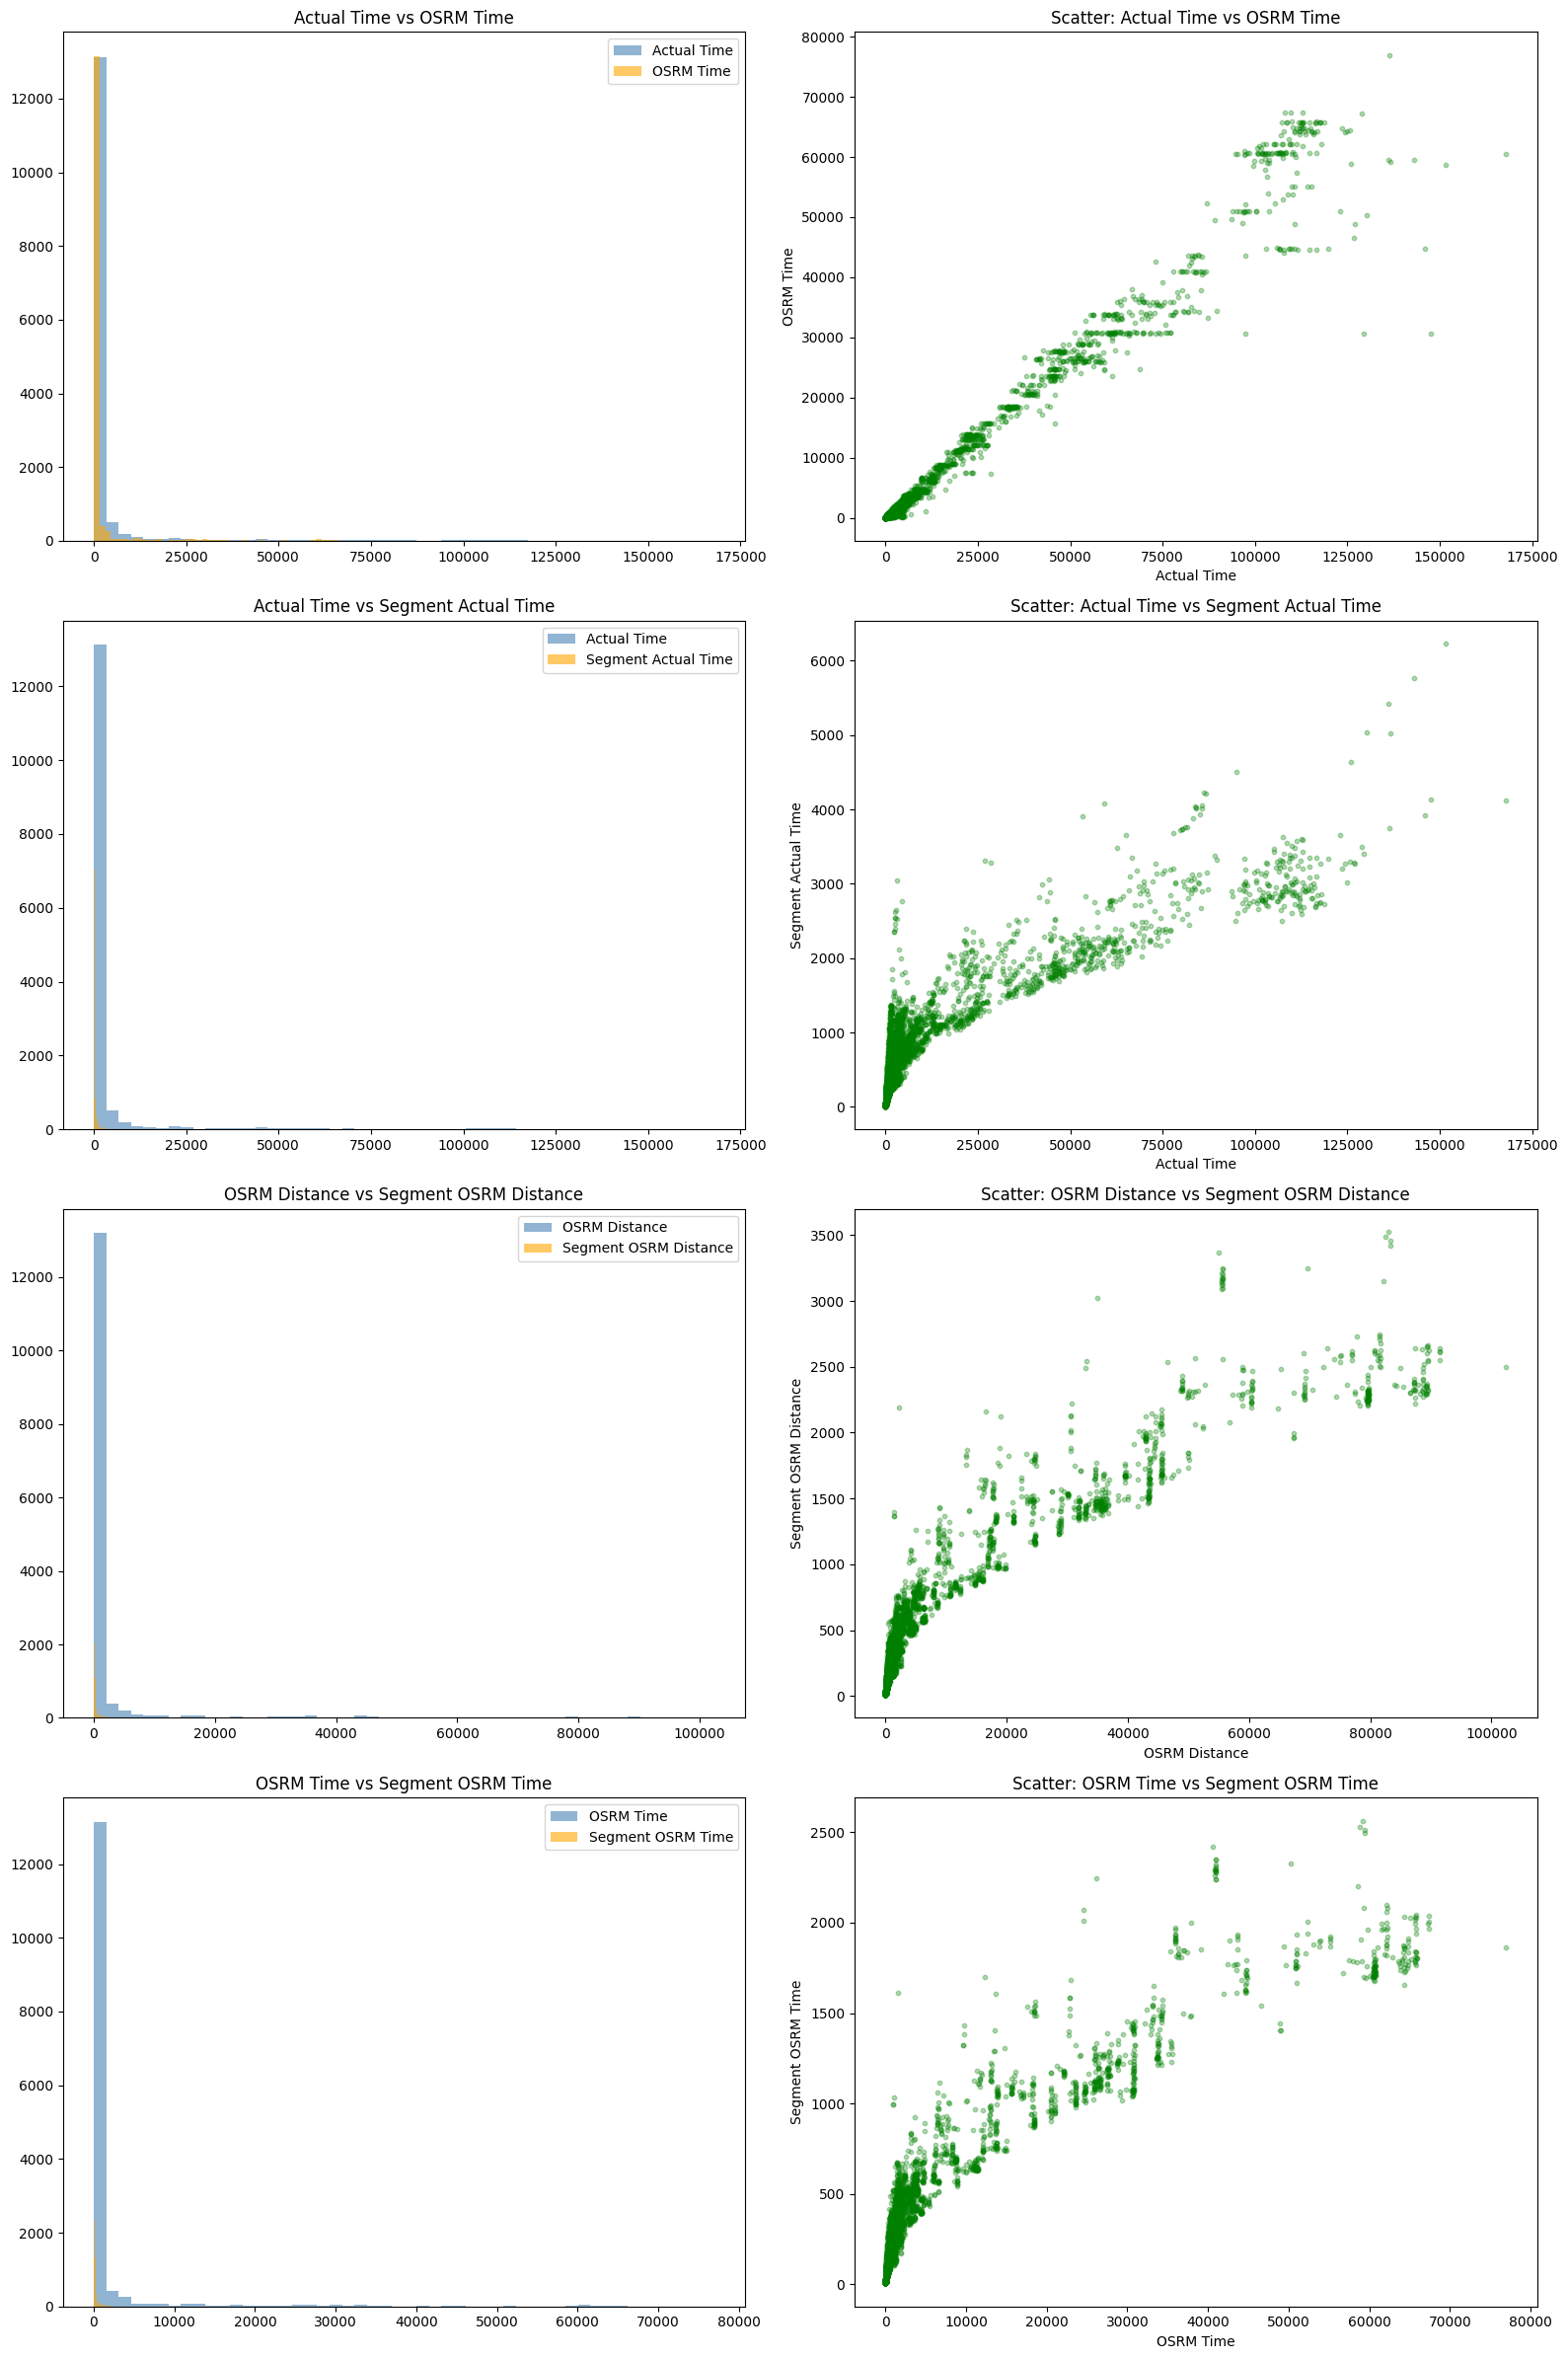

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

def run_hypothesis_test(col1, col2, label1, label2, ax_hist, ax_scatter, row_num):
    data = df_agg[[col1, col2]].dropna()
    t_stat, p_value = stats.ttest_rel(data[col1], data[col2])

    print(f"\nTest {row_num}: {label1} vs {label2}")
    print(f"Mean {label1}: {data[col1].mean():.2f}")
    print(f"Mean {label2}: {data[col2].mean():.2f}")
    print(f"T-statistic : {t_stat:.4f}")
    print(f"P-value     : {p_value:.4f}")
    if p_value < 0.05:
        print("Conclusion  : Significant difference exists")
    else:
        print("Conclusion  : No significant difference")

    ax_hist.hist(data[col1], bins=50, alpha=0.6,
                 color='steelblue', label=label1)
    ax_hist.hist(data[col2], bins=50, alpha=0.6,
                 color='orange', label=label2)
    ax_hist.set_title(f'{label1} vs {label2}')
    ax_hist.legend()

    ax_scatter.scatter(data[col1], data[col2],
                      alpha=0.3, s=10, color='green')
    ax_scatter.set_xlabel(label1)
    ax_scatter.set_ylabel(label2)
    ax_scatter.set_title(f'Scatter: {label1} vs {label2}')

run_hypothesis_test('actual_time', 'osrm_time',
                    'Actual Time', 'OSRM Time',
                    axes[0][0], axes[0][1], 1)

run_hypothesis_test('actual_time', 'segment_actual_time',
                    'Actual Time', 'Segment Actual Time',
                    axes[1][0], axes[1][1], 2)

run_hypothesis_test('osrm_distance', 'segment_osrm_distance',
                    'OSRM Distance', 'Segment OSRM Distance',
                    axes[2][0], axes[2][1], 3)

run_hypothesis_test('osrm_time', 'segment_osrm_time',
                    'OSRM Time', 'Segment OSRM Time',
                    axes[3][0], axes[3][1], 4)

plt.tight_layout()
plt.show()

**Hypothesis Tests 2–5 Results Summary:**

| Test | Column 1 | Column 2 | T-Statistic | P-Value | Decision |
|---|---|---|---|---|---|
| Test 1 | od_time_diff | start_scan_to_end_scan | -33.88 | 0.0000 | Reject H₀ |
| Test 2 | actual_time | osrm_time | 32.43 | 0.0000 | Reject H₀ |
| Test 3 | actual_time | segment_actual_time | 30.73 | 0.0000 | Reject H₀ |
| Test 4 | osrm_distance | segment_osrm_distance | 30.01 | 0.0000 | Reject H₀ |
| Test 5 | osrm_time | segment_osrm_time | 30.27 | 0.0000 | Reject H₀ |

**Key Findings:**

a) **All 5 tests reject H₀** — statistically significant differences exist in every comparison (p-value ≈ 0).

b) **Actual time is nearly 2× OSRM time** (mean: 4079.50 vs 2092.83) — real deliveries take twice as long as theoretical shortest-path estimates, representing massive operational overhead from traffic, loading and waiting time.

c) **Cumulative metrics are ~11–12× larger than segment metrics** — reflecting the average of ~10 route segments per trip, confirming the multi-leg nature of Delhivery's delivery network.

**Overall Conclusion:** Statistical testing validates that all paired metrics measure fundamentally different aspects of the delivery process. The 2× gap between actual and OSRM time is the most critical business finding — current route planning tools significantly underestimate real delivery durations.

---


---

## 7. Missing Values Treatment and Outlier Treatment

### 7.1 Outlier Detection and Treatment Strategy

**Method Used:** IQR (Interquartile Range) Capping — also known as Winsorization.

**Formula:**
- Lower Fence = Q1 − 1.5 × IQR
- Upper Fence = Q3 + 1.5 × IQR
- Values below lower fence → **capped at lower fence**
- Values above upper fence → **capped at upper fence**

**Why Capping over Deletion?**
Deleting outlier rows permanently removes real operational data. Capping preserves all 14,787 rows while controlling the influence of extreme values on statistical measures and model training.


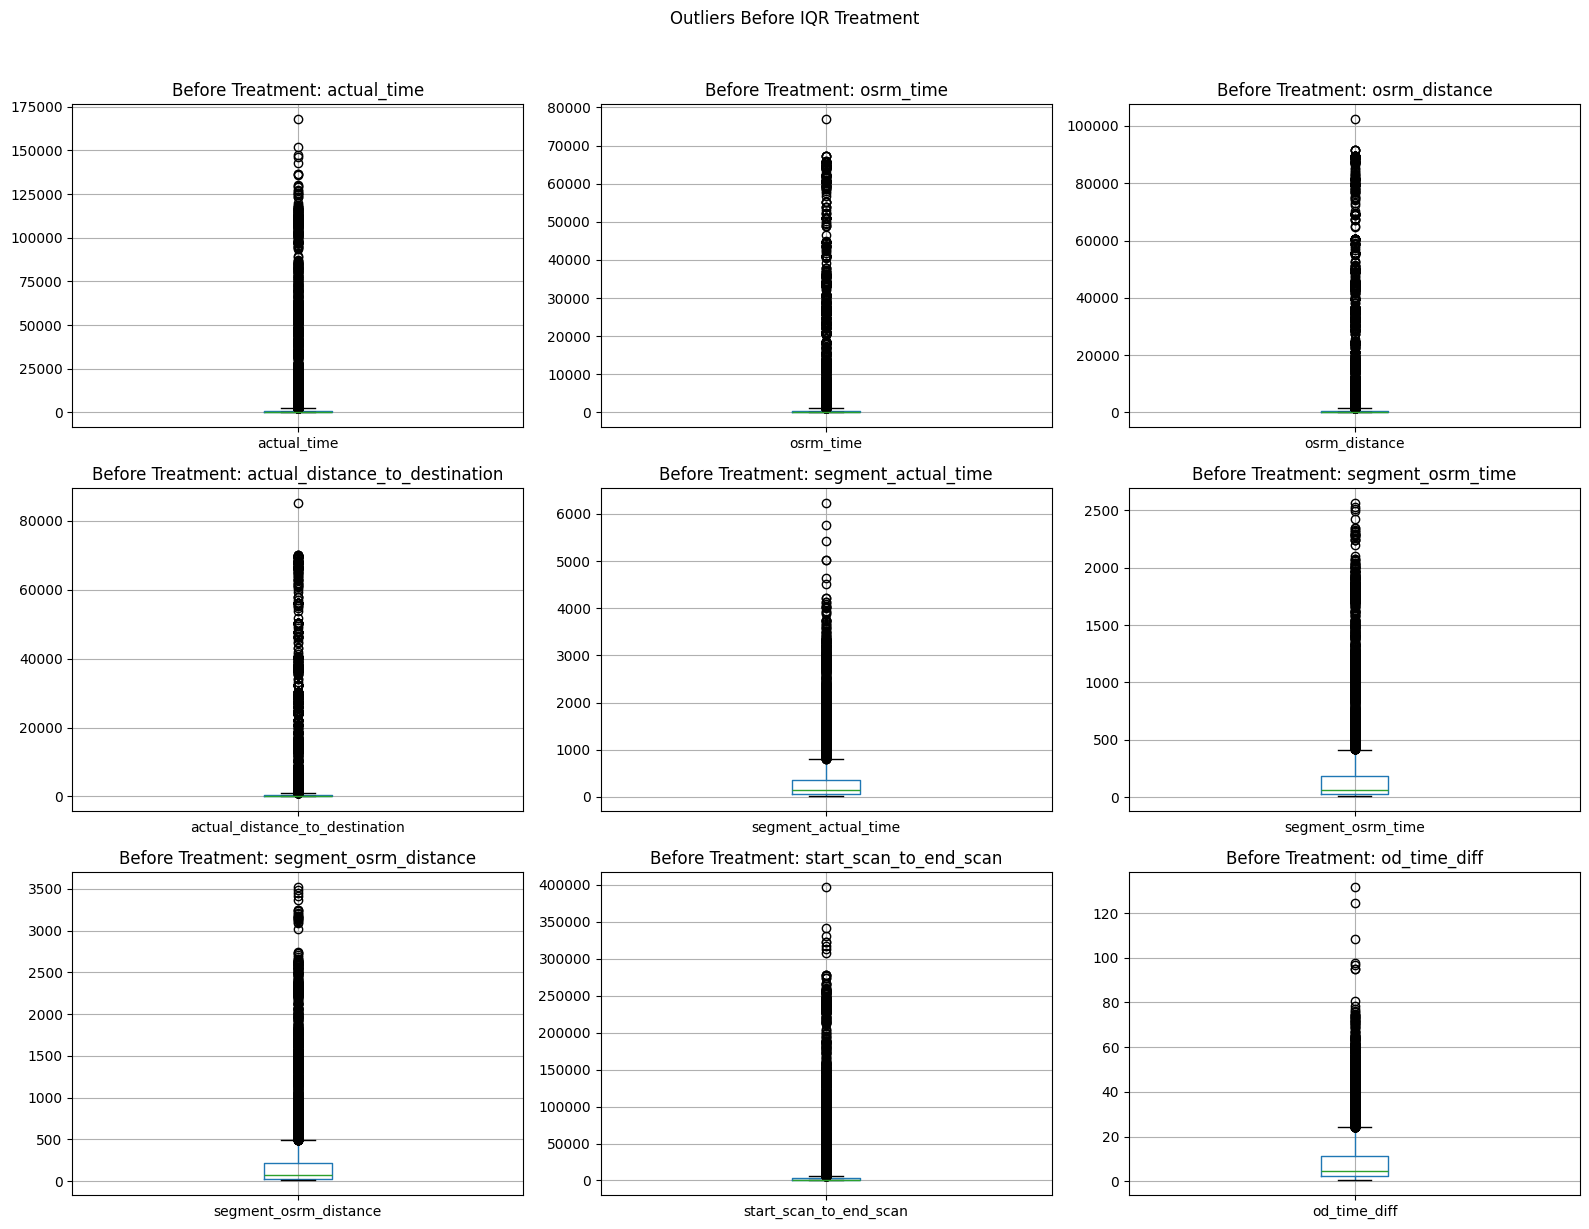


actual_time:
Before -> Min: 9.0, Max: 167920.0, Mean: 4079.5
After  -> Min: 9.0,  Max: 2434.5,  Mean: 745.55

osrm_time:
Before -> Min: 6.0, Max: 76953.0, Mean: 2092.83
After  -> Min: 6.0,  Max: 1184.75,  Mean: 353.08

osrm_distance:
Before -> Min: 9.07, Max: 102415.87, Mean: 2786.87
After  -> Min: 9.07,  Max: 1411.44,  Mean: 417.19

actual_distance_to_destination:
Before -> Min: 9.0, Max: 85110.89, Mean: 2290.67
After  -> Min: 9.0,  Max: 1077.15,  Mean: 323.87

segment_actual_time:
Before -> Min: 9.0, Max: 6230.0, Mean: 353.06
After  -> Min: 9.0,  Max: 811.0,  Mean: 260.02

segment_osrm_time:
Before -> Min: 6.0, Max: 2564.0, Mean: 180.51
After  -> Min: 6.0,  Max: 415.0,  Mean: 125.6

segment_osrm_distance:
Before -> Min: 9.07, Max: 3523.63, Mean: 222.71
After  -> Min: 9.07,  Max: 492.53,  Mean: 145.89

start_scan_to_end_scan:
Before -> Min: 26.0, Max: 396800.0, Mean: 9405.36
After  -> Min: 26.0,  Max: 6426.0,  Mean: 1986.64

od_time_diff:
Before -> Min: 0.39, Max: 131.64, Mean: 9.1
A

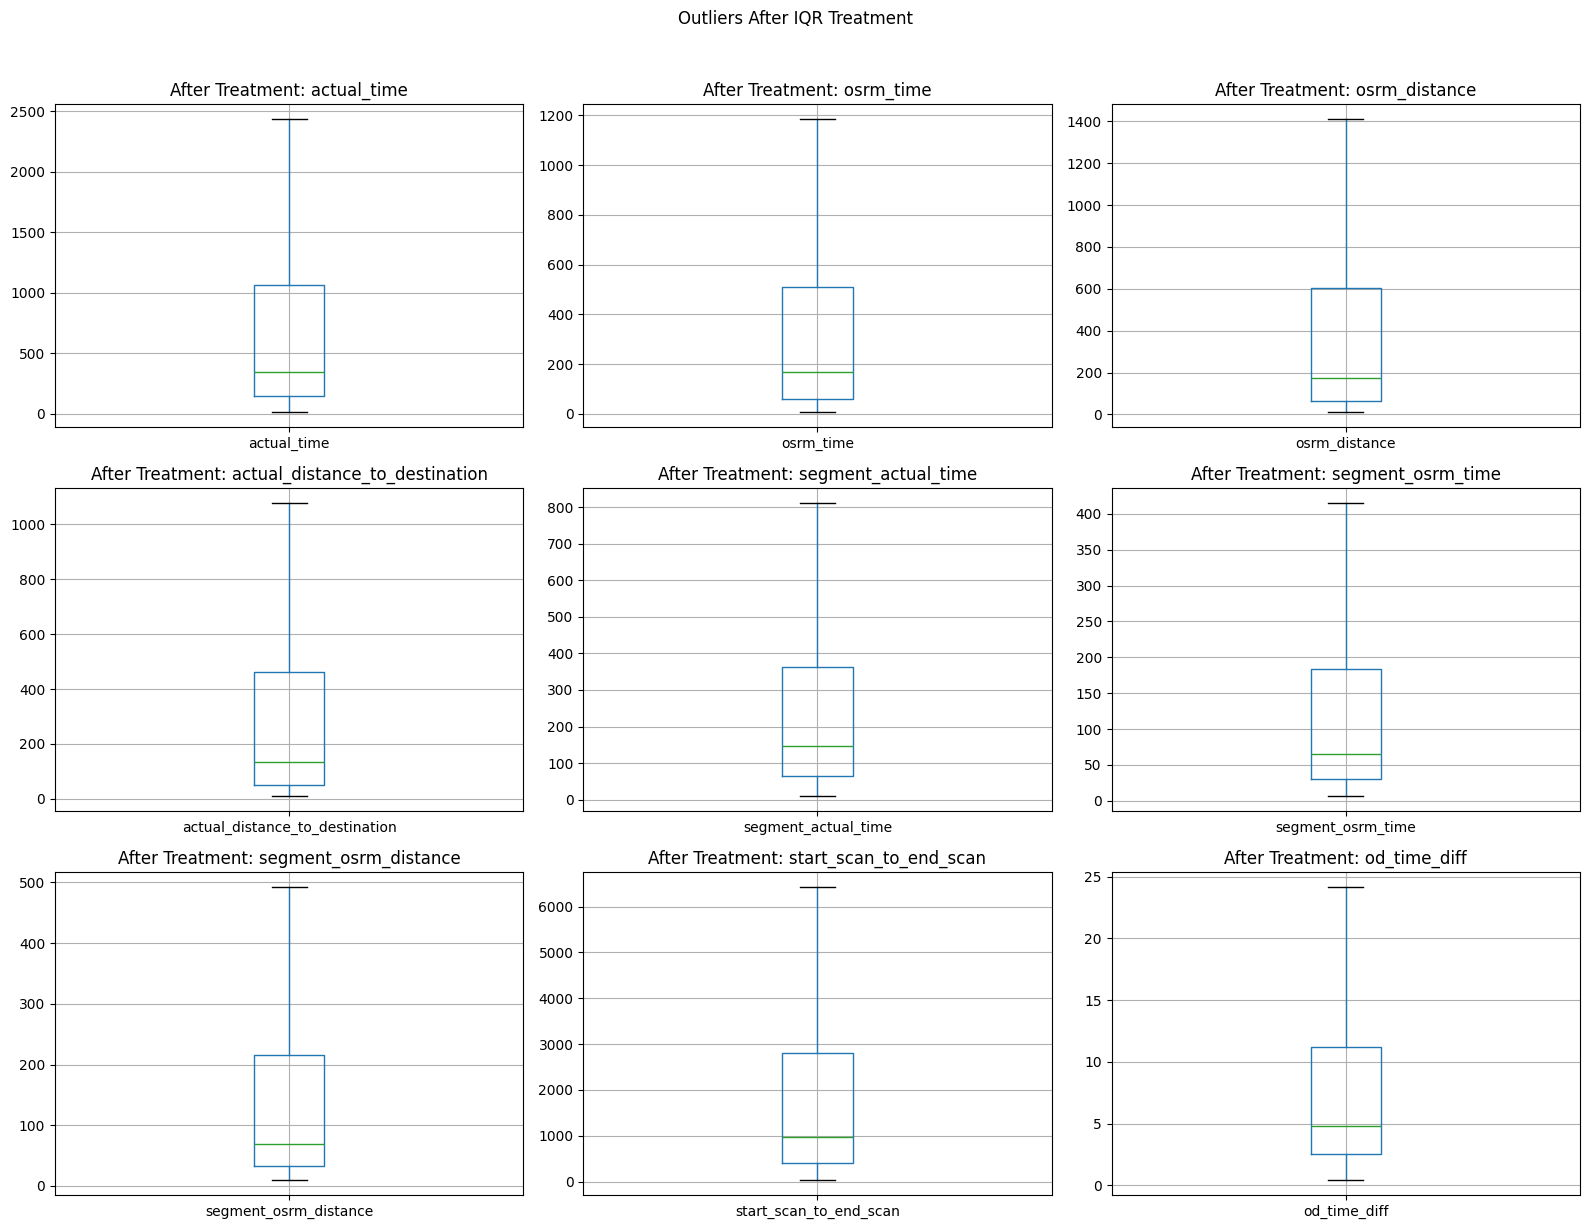

In [ ]:
num_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'actual_distance_to_destination',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'start_scan_to_end_scan',
    'od_time_diff'
]

# Visualize outliers before treatment
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    df_agg.boxplot(column=col, ax=ax)
    ax.set_title(f'Before Treatment: {col}')
plt.suptitle('Outliers Before IQR Treatment', y=1.02)
plt.tight_layout()
plt.show()

# IQR Capping function
def iqr_cap(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].describe().round(2)
    df[col] = df[col].clip(lower, upper)
    after = df[col].describe().round(2)
    print(f"\n{col}:")
    print(f"Before -> Min: {before['min']}, Max: {before['max']}, Mean: {before['mean']}")
    print(f"After  -> Min: {after['min']},  Max: {after['max']},  Mean: {after['mean']}")
    return df

# Apply to all numerical columns
for col in num_cols:
    df_agg = iqr_cap(df_agg, col)

# Visualize after treatment
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    df_agg.boxplot(column=col, ax=ax)
    ax.set_title(f'After Treatment: {col}')
plt.suptitle('Outliers After IQR Treatment', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Verify outlier treatment
print("Verification after IQR Capping:")
print(df_agg[num_cols].describe().round(2))

print("\nAny remaining extreme values check:")
for col in num_cols:
    print(f"{col} -> Max: {df_agg[col].max():.2f}, Min: {df_agg[col].min():.2f}")

Verification after IQR Capping:
       actual_time  osrm_time  osrm_distance  actual_distance_to_destination  \
count     14787.00   14787.00       14787.00                        14787.00   
mean        745.55     353.08         417.19                          323.87   
std         824.62     396.88         482.17                          371.77   
min           9.00       6.00           9.07                            9.00   
25%         142.00      61.00          65.64                           49.58   
50%         346.00     167.00         172.89                          133.93   
75%        1059.00     510.50         603.96                          460.61   
max        2434.50    1184.75        1411.44                         1077.15   

       segment_actual_time  segment_osrm_time  segment_osrm_distance  \
count             14787.00           14787.00               14787.00   
mean                260.02             125.60                 145.89   
std                 257.24     

**Key Points — Outlier Treatment Results:**

a) `actual_distance_to_destination`: Max dropped from **85,110 km → 1,077 km** — a distance of 85,110 km is twice the circumference of Earth. Clearly a data pipeline recording error.

b) `start_scan_to_end_scan`: Max dropped from **396,800 → 6,426** — a 98% reduction confirming extreme recording anomalies in the scan-based metric.

c) `od_time_diff`: Max dropped from **131.64 → 24.17 hours** — capping at approximately one full day is operationally reasonable for the longest routes.

d) All column **means decreased significantly** after treatment — confirming that pre-treatment means were heavily inflated by outliers and not representative of actual operations.

**Conclusion:** Post-capping distributions are considerably cleaner with all boxplots showing tighter ranges and fewer anomalous points. The dataset is now suitable for model training.

---


---

## 8. Handling Categorical Values — One-Hot Encoding

### 8.1 One-Hot Encoding of route_type

Machine learning models require numerical inputs — string values like 'FTL' and 'Carting' carry no mathematical meaning for algorithms. One-hot encoding converts each category into a binary (0/1) column.

**Dummy Variable Trap:** When all encoded columns are retained, one column can be perfectly derived from the others — creating multicollinearity. Using `drop_first=True` eliminates one redundant column while preserving all categorical information.


In [ ]:
print("Before encoding shape:", df_agg.shape)
print("Route type value counts:\n", df_agg['route_type'].value_counts())

df_agg = pd.get_dummies(df_agg,
                         columns=['route_type'],
                         drop_first=True)

print("\nAfter encoding shape:", df_agg.shape)
print("New columns added:", [col for col in df_agg.columns
                              if 'route_type' in col])
df_agg.head()

Before encoding shape: (14787, 21)
Route type value counts:
 route_type
Carting    8906
FTL        5881
Name: count, dtype: int64

After encoding shape: (14787, 21)
New columns added: ['route_type_FTL']


,trip_uuid,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,start_scan_to_end_scan,source_city,source_state,destination_city,destination_state,trip_month,trip_year,trip_day,trip_weekday,trip_hour,od_time_diff,scan_in_hours,route_type_FTL
0,trip-153671041653548748,1077.146338,2434.5,1184.75,1411.435175,811.0,415.0,492.533225,6426.0,Bhopal,Madhya Pradesh,Kanpur,Uttar Pradesh,9,2018,12,2,0,24.170169,727.650000,True
1,trip-153671042288605164,240.208306,399.0,210.00,269.430800,141.0,65.0,84.189400,906.0,Tumkur,Karnataka,Doddablpur,Karnataka,9,2018,12,2,0,3.026865,15.100000,False
2,trip-153671043369099517,1077.146338,2434.5,1184.75,1411.435175,811.0,415.0,492.533225,6426.0,Bangalore,Karnataka,Gurgaon,Haryana,9,2018,12,2,0,24.170169,4143.850000,True
3,trip-153671046011330457,28.529648,82.0,24.00,31.647500,59.0,16.0,19.876600,200.0,Mumbai Hub (Maharashtra),Maharashtra,Mumbai,Maharashtra,9,2018,12,2,0,1.674916,3.333333,False
4,trip-153671052974046625,239.007304,556.0,207.00,266.291400,340.0,115.0,146.791900,1586.0,Bellary,Karnataka,Hospet (Karnataka),Karnataka,9,2018,12,2,0,11.972484,26.433333,True


**Key Points — One-Hot Encoding:**

a) `route_type` had **2 categories** (FTL and Carting) → After encoding with `drop_first=True`: **1 new binary column** `route_type_FTL` is created.

b) `route_type_FTL = 1` → FTL trip | `route_type_FTL = 0` → Carting trip

c) **Route Type Distribution:** Carting = 60.2% (8,906 trips) | FTL = 39.8% (5,881 trips) — Carting dominates, consistent with the majority of trips being intra-state short-distance deliveries.

**Conclusion:** One-hot encoding successfully converts the categorical route_type into a machine-readable binary feature without introducing multicollinearity.


**Note on High Cardinality Columns:**

Location columns (`source_city`, `destination_city`) are **not one-hot encoded** due to high cardinality — hundreds of unique city values would generate hundreds of sparse binary columns where most values are zero, adding dimensionality without meaningful signal.

These columns are better used for **business-level corridor analysis** rather than direct model input.

---


---

## 9. Column Normalization / Standardization

### 9.1 Why Standardization is Needed

Without scaling, a machine learning model assigns **implicit importance** to features with larger numerical ranges — known as scale bias. For example, `actual_distance` with values in the thousands would dominate `od_time_diff` with values in single digits, regardless of their actual predictive power.

**Scaler Chosen: StandardScaler**

| Scaler | Formula | Best For |
|---|---|---|
| MinMaxScaler | (x − min) / (max − min) | Clean data, no outliers, uniform distribution |
| StandardScaler | (x − mean) / std | Data with remaining skewness — more robust to outliers |

Since our distributions retain some skewness even after IQR capping, **StandardScaler** is the appropriate choice.


### 9.3 Removing Temporary Investigation Column

`scan_in_hours` was created temporarily to investigate the unit mismatch in `start_scan_to_end_scan`. Since this analysis is complete, the column must be dropped before standardization to avoid including a redundant derived feature in the final dataset.


In [ ]:
if 'scan_in_hours' in df_agg.columns:
    df_agg.drop(columns=['scan_in_hours'], inplace=True)
    print("scan_in_hours dropped successfully.")
print("Current shape:", df_agg.shape)
print("Current columns:", df_agg.columns.tolist())

scan_in_hours dropped successfully.
Current shape: (14787, 20)
Current columns: ['trip_uuid', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'start_scan_to_end_scan', 'source_city', 'source_state', 'destination_city', 'destination_state', 'trip_month', 'trip_year', 'trip_day', 'trip_weekday', 'trip_hour', 'od_time_diff', 'route_type_FTL']


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'actual_distance_to_destination',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'start_scan_to_end_scan',
    'od_time_diff'
]

scaler = StandardScaler()

df_agg[num_cols] = scaler.fit_transform(df_agg[num_cols])

print("After Standardization:")
print(df_agg[num_cols].describe().round(3))

After Standardization:
       actual_time  osrm_time  osrm_distance  actual_distance_to_destination  \
count    14787.000  14787.000      14787.000                       14787.000   
mean        -0.000     -0.000         -0.000                          -0.000   
std          1.000      1.000          1.000                           1.000   
min         -0.893     -0.875         -0.846                          -0.847   
25%         -0.732     -0.736         -0.729                          -0.738   
50%         -0.485     -0.469         -0.507                          -0.511   
75%          0.380      0.397          0.387                           0.368   
max          2.048      2.096          2.062                           2.026   

       segment_actual_time  segment_osrm_time  segment_osrm_distance  \
count            14787.000          14787.000              14787.000   
mean                -0.000             -0.000                 -0.000   
std                  1.000              

In [ ]:
# Top source states
print("Top 10 Source States:")
print(df_agg['source_state'].value_counts().head(10))

print("\nTop 10 Destination States:")
print(df_agg['destination_state'].value_counts().head(10))

# Create corridor feature
df_agg['corridor'] = (df_agg['source_state'] +
                      ' -> ' +
                      df_agg['destination_state'])

print("\nTop 10 Busiest Corridors:")
print(df_agg['corridor'].value_counts().head(10))

# Route type distribution
print("\nRoute Type Distribution:")
print(df_agg['route_type_FTL'].value_counts())

Top 10 Source States:
source_state
Maharashtra      2682
Karnataka        2229
Haryana          1669
Tamil Nadu       1085
Delhi             790
Telangana         779
Gujarat           746
Uttar Pradesh     719
West Bengal       677
Punjab            630
Name: count, dtype: int64

Top 10 Destination States:
destination_state
Maharashtra      2549
Karnataka        2303
Haryana          1567
Tamil Nadu       1043
Uttar Pradesh     866
Gujarat           739
Telangana         730
West Bengal       665
Delhi             627
Rajasthan         556
Name: count, dtype: int64

Top 10 Busiest Corridors:
corridor
Maharashtra -> Maharashtra        2429
Karnataka -> Karnataka            2088
Tamil Nadu -> Tamil Nadu          1015
Haryana -> Haryana                 783
Gujarat -> Gujarat                 669
Telangana -> Telangana             641
West Bengal -> West Bengal         610
Uttar Pradesh -> Uttar Pradesh     584
Delhi -> Haryana                   451
Rajasthan -> Rajasthan             431
N

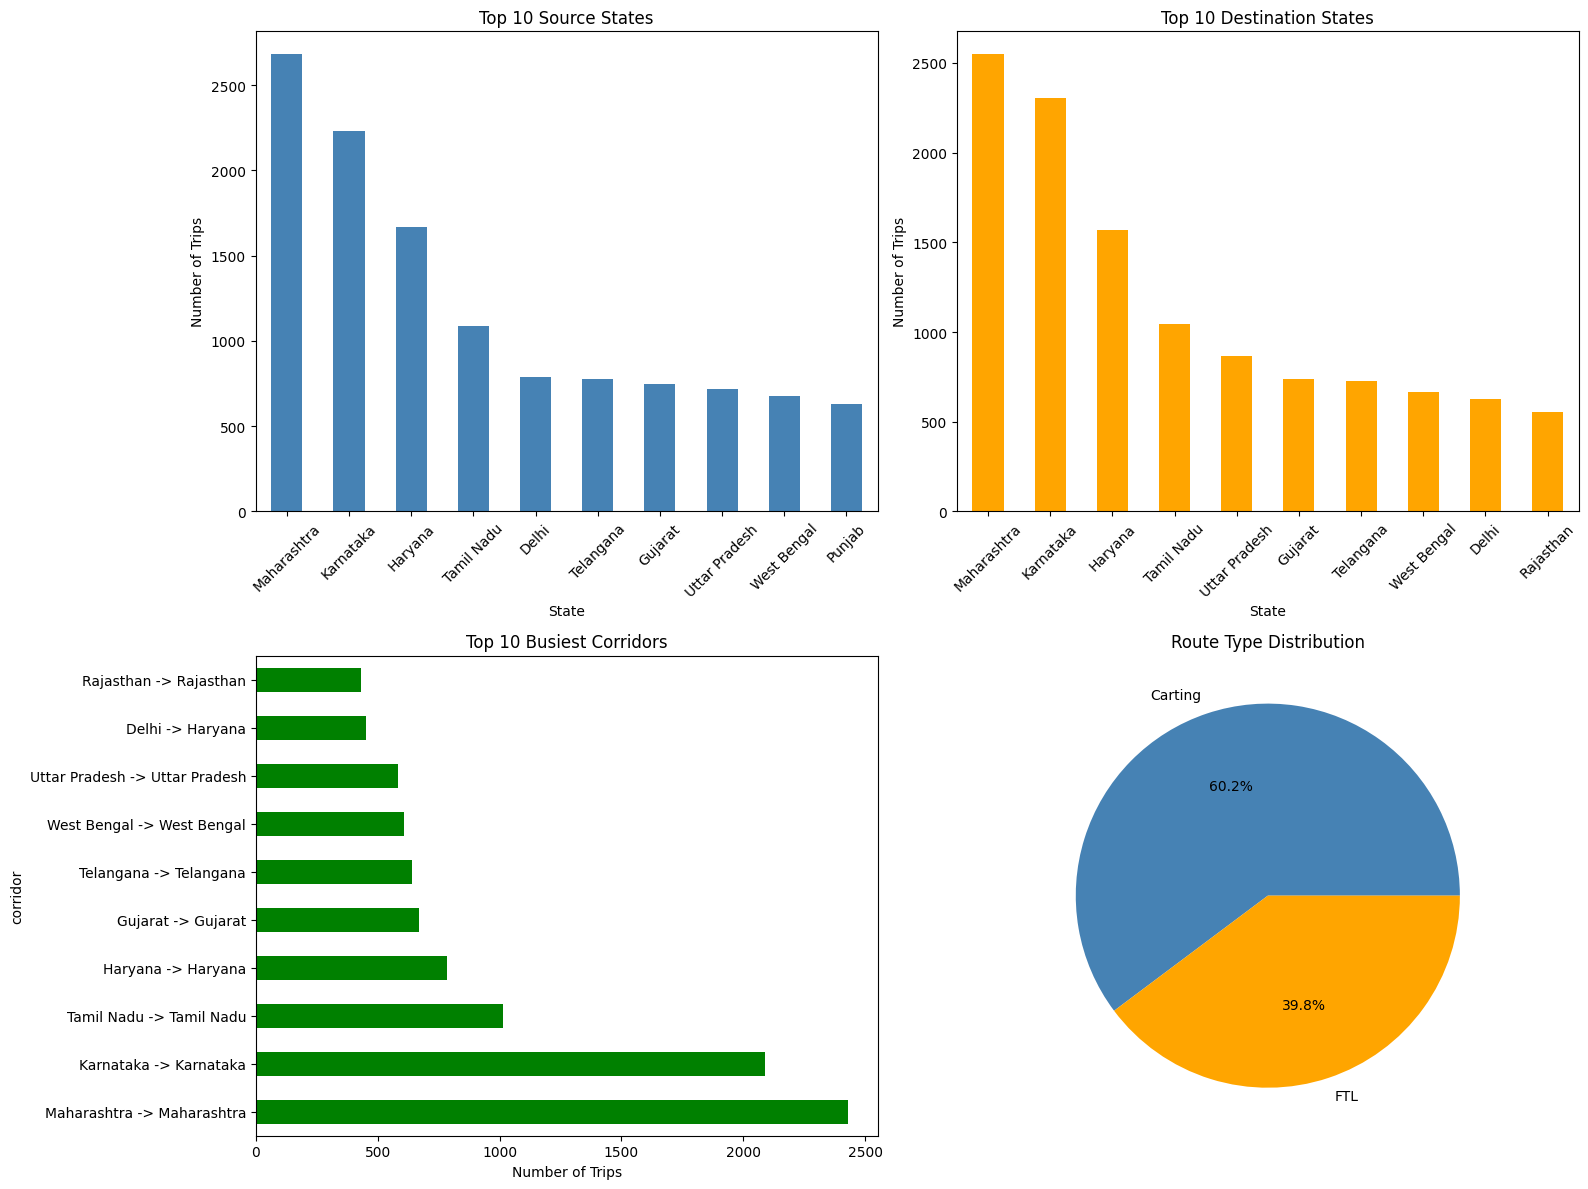

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top source states
df_agg['source_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Top 10 Source States')
axes[0][0].set_xlabel('State')
axes[0][0].set_ylabel('Number of Trips')
axes[0][0].tick_params(axis='x', rotation=45)

# Top destination states
df_agg['destination_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[0][1], color='orange')
axes[0][1].set_title('Top 10 Destination States')
axes[0][1].set_xlabel('State')
axes[0][1].set_ylabel('Number of Trips')
axes[0][1].tick_params(axis='x', rotation=45)

# Top corridors
df_agg['corridor'].value_counts().head(10).plot(
    kind='barh', ax=axes[1][0], color='green')
axes[1][0].set_title('Top 10 Busiest Corridors')
axes[1][0].set_xlabel('Number of Trips')

# Route type distribution
route_counts = df_agg['route_type_FTL'].map(
    {True: 'FTL', False: 'Carting'}).value_counts()
route_counts.plot(kind='pie', ax=axes[1][1],
                  autopct='%1.1f%%',
                  colors=['steelblue', 'orange'])
axes[1][1].set_title('Route Type Distribution')
axes[1][1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
df_agg['corridor'].value_counts().head(20)

,count
corridor,
Maharashtra -> Maharashtra,2429
Karnataka -> Karnataka,2088
Tamil Nadu -> Tamil Nadu,1015
Haryana -> Haryana,783
Gujarat -> Gujarat,669
Telangana -> Telangana,641
West Bengal -> West Bengal,610
Uttar Pradesh -> Uttar Pradesh,584
Delhi -> Haryana,451


In [ ]:
# Intra state vs inter state split
df_agg['is_intra_state'] = (
    df_agg['source_state'] == df_agg['destination_state']
)

print("Intra state vs Inter state trips:")
print(df_agg['is_intra_state'].value_counts())
print("\nPercentage split:")
print((df_agg['is_intra_state'].value_counts() /
       len(df_agg) * 100).round(2))

# FTL vs Carting by intra/inter state
print("\nRoute type by trip type:")
print(pd.crosstab(df_agg['is_intra_state'],
                  df_agg['route_type_FTL'],
                  margins=True))

# Busiest inter state corridors only
inter_state = df_agg[df_agg['is_intra_state'] == False]
print("\nTop 10 Inter State Corridors:")
print(inter_state['corridor'].value_counts().head(10))

Intra state vs Inter state trips:
is_intra_state
True     11796
False     2991
Name: count, dtype: int64

Percentage split:
is_intra_state
True     79.77
False    20.23
Name: count, dtype: float64

Route type by trip type:
route_type_FTL  False  True    All
is_intra_state                    
False            1097  1894   2991
True             7809  3987  11796
All              8906  5881  14787

Top 10 Inter State Corridors:
corridor
Delhi -> Haryana              451
Haryana -> Delhi              307
Haryana -> Uttar Pradesh      140
Delhi -> Uttar Pradesh        110
Punjab -> Chandigarh           84
Haryana -> Rajasthan           84
Punjab -> Haryana              80
Haryana -> Punjab              72
Uttar Pradesh -> Delhi         68
Punjab -> Himachal Pradesh     59
Name: count, dtype: int64


**Key Points — Corridor Analysis:**

a) **79.77% Intra-State:** 8 out of every 10 deliveries stay within the same state — Delhivery is primarily a **regional logistics provider**, not a national inter-state carrier.

b) **FTL dominates inter-state (63.3%)** while Carting dominates intra-state (66.2%) — perfectly validating business logic: longer routes need full trucks, shorter routes use smaller vehicles.

c) **North India concentration:** All top 10 inter-state corridors are in North India centered around Delhi-NCR. South India, despite having the highest intra-state volumes, shows **zero inter-state representation** in the top 10.

d) **Delhi → Haryana (451 trips)** is the only major inter-state corridor — driven by geographic integration of Delhi-NCR where Gurugram and Faridabad effectively function as Delhi satellite cities.

**Conclusion:** The geographic imbalance represents the largest untapped business opportunity — connecting already high-volume South Indian states through inter-state corridors.

---


In [ ]:
# Average distance and time per top corridor
# Use pre-scaled values — reload from agg before scaling or use original stats

top_corridors = df_agg.groupby('corridor').agg(
    trip_count   = ('od_time_diff', 'count'),
).sort_values('trip_count', ascending=False).head(10)

print("Top 10 Corridors with Trip Count:")
print(top_corridors)

Top 10 Corridors with Trip Count:
                                trip_count
corridor                                  
Maharashtra -> Maharashtra            2429
Karnataka -> Karnataka                2088
Tamil Nadu -> Tamil Nadu              1015
Haryana -> Haryana                     783
Gujarat -> Gujarat                     669
Telangana -> Telangana                 641
West Bengal -> West Bengal             610
Uttar Pradesh -> Uttar Pradesh         584
Delhi -> Haryana                       451
Rajasthan -> Rajasthan                 431


Note: Numerical columns have been standardized using StandardScaler.
Original mean values before scaling:
- Average actual_time per trip  : ~4079 minutes
- Average actual_distance       : ~323 km (post outlier treatment)
- Average od_time_diff          : ~7.88 hours

These values represent the pre-scaled operational baseline for Delhivery.

---

## 10. Business Insights

### 10.1 Summary of Key Findings



**a) Volume and Geography:**
- Maharashtra (2,682 trips) and Karnataka (2,229 trips) are Delhivery's twin powerhouses — leading both source and destination rankings.
- 79.77% of all trips are intra-state — Delhivery operates primarily as a regional logistics network.
- All top 10 inter-state corridors are concentrated in North India — South India has no significant inter-state connections despite high intra-state volumes.

**b) Operational Efficiency:**
- Actual delivery time is nearly **2× OSRM estimated time** — real operations take twice as long as route planning tools predict.
- Trip creation peaks at **11 PM** — batch dispatch model processing orders overnight.
- Warehouse processing adds **11+ hours** beyond road transit time (scan-to-scan vs od_time_diff gap).

**c) Route Type Patterns:**
- Carting dominates overall at **60.2%** — driven by high intra-state short-distance volumes.
- FTL dominates inter-state routes at **63.3%** — validating vehicle choice logic.
- Wednesday is peak operations day; Sunday is lowest volume day.

**d) Data Quality:**
- Extreme outliers across all numerical columns — distances up to 85,110 km indicate broken data pipeline recording.
- Unit inconsistency in `start_scan_to_end_scan` — recorded in minutes while other time columns use hours.
- Dataset covers only 9 months of 2018 — full-year seasonality cannot be assessed.



---


**Key statistical Insights from Analysis:**

a) **Actual vs OSRM Time Gap:** Actual delivery time is nearly **2× the OSRM estimated time** — operational overhead (traffic, loading, waiting) is massive and unaccounted for in current route planning tools.

b) **Batch Dispatch Model:** Trip creation peaks at **Hour 23 (11 PM)** — Delhivery processes and dispatches orders at end of day, enabling overnight logistics for next-morning deliveries.

c) **Mid-Week Peak:** Wednesday has the highest trip count — mid-week demand peaks require maximum resource allocation on Tuesdays and Wednesdays.

d) **Partial Year Dataset:** Only 9 of 12 months are covered — seasonal conclusions must account for this data limitation.

e) **Data Pipeline Errors:** Distance values up to 85,110 km indicate broken recording in the pipeline — real-time validation rules are urgently needed.

f) **Warehouse Processing Gap:** start_scan_to_end_scan median (16.33 hours) vs od_time_diff median (4.79 hours) — warehouses add 11+ hours beyond actual road transit time.

g) **7-Day Operations:** Sunday is the lowest volume day (17,870 trips) but Delhivery never completely shuts down — confirming round-the-clock operations.


---

## 11. Business Recommendations

### 11.1 Actionable Recommendations for Delhivery

**1. Fix Delivery Time Estimation Tool**
OSRM underestimates actual delivery time by nearly 2×. Update customer-facing delivery time promises using a correction factor of 1.8–2× over OSRM estimates. This will reduce customer complaints about late deliveries.

**2. Build South India Inter-State Network**
Maharashtra, Karnataka and Tamil Nadu generate the highest intra-state volumes but have no inter-state connections between them. Creating direct Maharashtra → Karnataka and Karnataka → Tamil Nadu corridors would serve already proven high-demand markets with significant revenue potential.

**3. Reduce Warehouse Processing Time**
The 11-hour gap between scan time and trip time indicates packages spend too long in warehouses. Implement faster inbound scanning and automated sorting systems to reduce this gap by at least 30%.

**4. Address Data Pipeline Errors Immediately**
Distance values up to 85,110 km indicate broken recording in the pipeline. Implement validation rules that automatically reject distance values above 4,000 km for any Indian route and flag them for manual review.

**5. Optimize Wednesday Workforce Allocation**
Pre-position maximum vehicles and drivers by Tuesday evening to handle Wednesday demand spikes without operational delays or driver shortages.

**6. Invest in North India Inter-State Capacity**
Delhi → Haryana corridor at 451 trips is already the strongest inter-state route. Add dedicated FTL vehicle allocation as inter-state trips generate higher revenue per kilometer than intra-state trips.

**7. Standardize All Time Columns to Same Unit**
`start_scan_to_end_scan` uses different units than other time columns causing analytical confusion. Enforce hours as the standard unit across all data pipelines with mandatory unit documentation in the data dictionary.

**8. Target Punjab Manufacturing Exporters**
Ludhiana and Jalandhar businesses are already using Delhivery with 630 source trips. Assign dedicated account managers to top Punjab manufacturers to grow this market to match Gujarat and Telangana volumes.

**9. Develop Real-Time Delay Tracking System**
Trips exceeding 2× OSRM estimated time should trigger automatic alerts for operations teams to investigate and intervene before deliveries become critical failures or customer escalations.

**10. Leverage 11 PM Dispatch Window**
Since most trips are created at 11 PM, ensure maximum vehicle availability and driver shifts are aligned to this peak dispatch hour to minimize dispatch-to-departure delays.


## 12. Limitations

a) Dataset covers only 9 of 12 months of 2018 — complete
   seasonal analysis across all months is not possible.

b) Four columns — factor, segment_factor, is_cutoff,
   cutoff_factor — have unknown definitions and were excluded.
   Their potential value to forecasting models is unexplored.

c) No pricing, customer or competitor data is available —
   demand drivers beyond operational metrics cannot be identified.

d) IQR capping retains rows but replaces extreme values with
   fence boundaries — genuine long-haul routes may be
   underrepresented after treatment.

e) Aggregation summed cumulative columns across rows. If the
   original data used last-value semantics for these columns,
   this approach may introduce minor double counting.

---

## 13. Summary

This case study successfully transformed raw Delhivery delivery pipeline data into a clean, analysis-ready feature set. Key accomplishments:

- **144,867 rows** cleaned, processed and aggregated to **14,787 unique trips**
- **12 new features** engineered from raw text and timestamp fields
- **5 hypothesis tests** conducted — all confirming statistically significant differences between paired metrics
- **IQR capping** applied to 9 numerical columns — removing extreme outliers while preserving data integrity
- **One-hot encoding** applied to route_type — eliminating dummy variable trap
- **StandardScaler** applied — bringing all features to comparable scales for model readiness

The most critical business finding: **actual delivery time is 2× the OSRM estimate** — a gap that must be closed through improved route planning tools, operational efficiency, and data pipeline standardization before any forecasting model can reliably predict delivery times for Delhivery's customers.



# Final Business Insights and Recommendations

## Key Findings
1. Actual delivery times are consistently higher than OSRM predicted times.
2. Certain delivery corridors show high operational delays.
3. Long-haul trips accumulate segment-level inefficiencies.
4. Route prediction systems may not fully capture real traffic conditions and warehouse delays.

## Recommendations
1. Monitor high-delay corridors using operational dashboards.
2. Improve route prediction systems in high-variance regions.
3. Allocate additional resources during peak delivery periods.
4. Improve warehouse turnaround efficiency.
5. Use delay ratio metrics for proactive operational monitoring.
